In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import math
from pathlib import Path

plt.rcParams.update({
    'font.size': 16,            # Default font size
    'axes.titlesize': 18,       # Title font size
    'axes.labelsize': 16,       # Axis label font size
    'xtick.labelsize': 14,      # X tick label font size
    'ytick.labelsize': 14,      # Y tick label font size
    'legend.fontsize': 14,      # Legend font size
})


# Procgen

## Normalised

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

# ----------------------------
# Load data
# ----------------------------
planning_csv = Path("/Users/Student/wm_inference_diffusion/src/procgen_planning_per_run.csv")
baseline_csv = Path("/Users/Student/wm_inference_diffusion/src/procgen_baseline_per_run.csv")

planning_df = pd.read_csv(planning_csv)
baseline_df = pd.read_csv(baseline_csv)

# ----------------------------
# Procgen hard-mode normalisation constants
# ----------------------------
R_MIN = {
    "CoinRun": 5.0, "StarPilot": 1.5, "CaveFlyer": 2.0, "Dodgeball": 1.5,
    "FruitBot": -0.5, "Chaser": 0.5, "Miner": 1.5, "Jumper": 1.0,
    "Leaper": 1.5, "Maze": 4.0, "BigFish": 0.0, "Heist": 2.0,
    "Climber": 1.0, "Plunder": 3.0, "Ninja": 2.0, "BossFight": 0.5,
}

R_MAX = {
    "CoinRun": 10.0, "StarPilot": 35.0, "CaveFlyer": 13.4, "Dodgeball": 19.0,
    "FruitBot": 27.2, "Chaser": 14.2, "Miner": 20.0, "Jumper": 10.0,
    "Leaper": 10.0, "Maze": 10.0, "BigFish": 40.0, "Heist": 10.0,
    "Climber": 12.6, "Plunder": 30.0, "Ninja": 10.0, "BossFight": 13.0,
}

def compute_iqm(values):
    values = np.sort(np.asarray(values, dtype=float))
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    lower = int(np.floor(0.25 * len(values)))
    upper = int(np.ceil(0.75 * len(values)))
    trimmed = values[lower:upper]

    if len(trimmed) == 0:
        return np.nan

    return trimmed.mean()

def add_normalised_score(df, reward_col="final_reward"):
    df = df.copy()
    df = df.dropna(subset=["env_type", reward_col])

    def _normalise(row):
        env = row["env_type"]
        reward = row[reward_col]

        if env not in R_MIN or env not in R_MAX:
            return np.nan

        denom = R_MAX[env] - R_MIN[env]
        if denom == 0:
            return np.nan

        return (reward - R_MIN[env]) / denom

    df["norm_score"] = df.apply(_normalise, axis=1)
    return df

def compute_normalised_iqm(planning_df, baseline_df):
    planning_df = add_normalised_score(planning_df, reward_col="final_reward")
    baseline_df = add_normalised_score(baseline_df, reward_col="final_reward")

    rows = []

    # ---- baseline ----
    base_vals = baseline_df["norm_score"].dropna().values
    mean, low, high = bootstrap_iqm_ci(base_vals)

    rows.append({
        "experiment": "baseline",
        "planning_steps": 0,
        "planning_percentage": np.nan,
        "planning_mode": "baseline",
        "iqm": mean,
        "iqm_low": low,
        "iqm_high": high,
    })

    # ---- planning ----
    for (steps, pp, mode), sub in planning_df.groupby(
        ["planning_steps", "planning_percentage", "planning_mode"]
    ):
        vals = sub["norm_score"].dropna().values
        mean, low, high = bootstrap_iqm_ci(vals)

        rows.append({
            "experiment": "planning",
            "planning_steps": steps,
            "planning_percentage": pp,
            "planning_mode": mode,
            "iqm": mean,
            "iqm_low": low,
            "iqm_high": high,
        })

    return pd.DataFrame(rows)


def bootstrap_iqm_ci(values, n_boot=1000):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    iqms = []
    n = len(values)

    for _ in range(n_boot):
        sample = np.random.choice(values, size=n, replace=True)
        iqms.append(compute_iqm(sample))

    iqms = np.array(iqms)

    mean = compute_iqm(values)
    lower = np.percentile(iqms, 25)
    upper = np.percentile(iqms, 75)

    return mean, lower, upper

# ----------------------------
# Run
# ----------------------------
iqm_df = compute_normalised_iqm(planning_df, baseline_df)
print(iqm_df)
iqm_df.to_csv("procgen_iqm_per_experiment.csv", index=False)

   experiment  planning_steps  planning_percentage planning_mode       iqm  \
0    baseline               0                  NaN      baseline -0.087425   
1    planning               5                 0.05        reward -0.080268   
2    planning               5                 0.05         value -0.080908   
3    planning               5                 0.10        reward -0.076999   
4    planning               5                 0.10         value -0.077892   
5    planning               5                 0.20        reward -0.071325   
6    planning               5                 0.20         value -0.079275   
7    planning               5                 0.50        reward -0.064098   
8    planning               5                 0.50         value -0.069709   
9    planning              10                 0.05        reward -0.077305   
10   planning              10                 0.05         value -0.081133   
11   planning              10                 0.10        reward

In [3]:
def plot_iqm(iqm_df):
    planning_steps_order = [5, 10]
    planning_percentage_order = [0.05, 0.1, 0.2, 0.5]
    modes = ["value", "reward"]

    mode_colors = {
        "value": "tab:blue",
        "reward": "tab:orange",
    }

    # ----------------------------
    # X labels
    # ----------------------------
    group_labels = [
        f"{steps}\n{pp}"
        for steps in planning_steps_order
        for pp in planning_percentage_order
    ]

    x = np.arange(len(group_labels))
    width = 0.35

    # ----------------------------
    # Baseline
    # ----------------------------
    baseline_row = iqm_df[iqm_df["experiment"] == "baseline"]
    baseline_iqm = baseline_row["iqm"].iloc[0] if not baseline_row.empty else None

    # ----------------------------
    # Plot
    # ----------------------------
    plt.figure(figsize=(12, 5))

    # baseline shaded region
    if baseline_iqm is not None and not np.isnan(baseline_iqm):
        plt.axhspan(
            baseline_iqm * 0.95,
            baseline_iqm * 1.05,
            color="grey",
            alpha=0.2,
            label="baseline ±5%"
        )
        plt.axhline(baseline_iqm, color="grey", linestyle="--", linewidth=1)

    # ----------------------------
    # Bars
    # ----------------------------
    for mode in modes:
        # inside plotting loop
        means = []
        yerr_lower = []
        yerr_upper = []

        for steps in planning_steps_order:
            for pp in planning_percentage_order:
                row = iqm_df[
                    (iqm_df["planning_steps"] == steps) &
                    (iqm_df["planning_percentage"] == pp) &
                    (iqm_df["planning_mode"] == mode)
                ]

                if row.empty:
                    means.append(np.nan)
                    yerr_lower.append(0)
                    yerr_upper.append(0)
                else:
                    m = row["iqm"].iloc[0]
                    lo = row["iqm_low"].iloc[0]
                    hi = row["iqm_high"].iloc[0]

                    means.append(m)
                    yerr_lower.append(m - lo)
                    yerr_upper.append(hi - m)

        yerr = np.vstack([yerr_lower, yerr_upper])
        offset = -width/2 if mode == "value" else width/2

        plt.bar(
            x + offset,
            means,
            width=width,
            yerr=yerr,
            capsize=3,
            color=mode_colors[mode],
            label=mode
        )

    # ----------------------------
    # Formatting
    # ----------------------------
    plt.xticks(x, group_labels)
    plt.xlabel("planning_steps / planning_percentage")
    plt.ylabel("Normalised IQM score")
    plt.title("Procgen Performance (Normalised IQM)")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

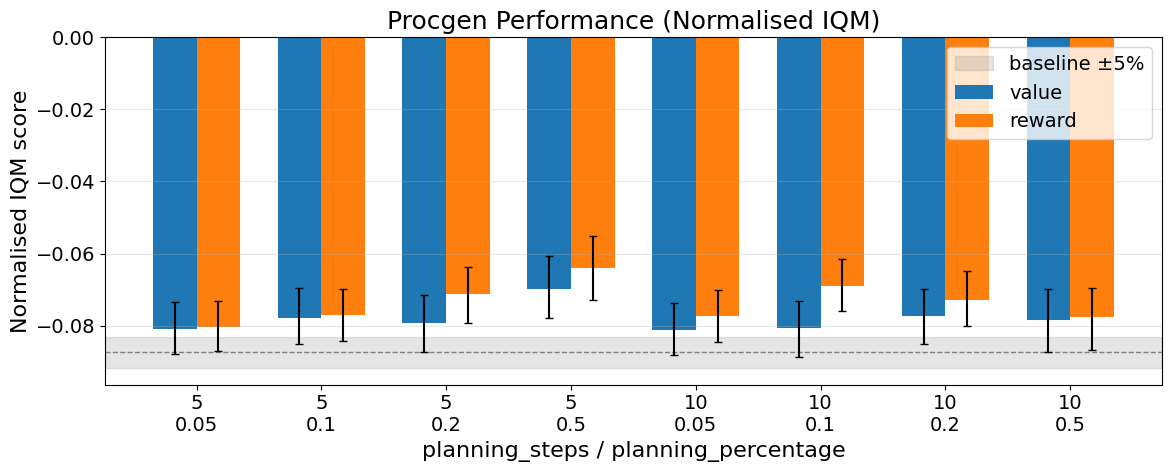

In [21]:
plot_iqm(iqm_df)

## Aggregated resutls

In [8]:
# ----------------------------
# Load data
# ----------------------------
planning_csv = Path("/Users/Student/wm_inference_diffusion/src/procgen_planning_summary.csv")
baseline_csv = Path("/Users/Student/wm_inference_diffusion/src/procgen_baseline_summary.csv")

planning_df = pd.read_csv(planning_csv)
baseline_df = pd.read_csv(baseline_csv)

def plot_metric(
    planning_df,
    baseline_df,
    value_col,
    std_col,
    ylabel,
    title,
):
    planning_steps_order = [5, 10]
    planning_percentage_order = [0.05, 0.1, 0.2, 0.5]
    modes = ["value", "reward"]

    mode_colors = {
        "value": "tab:blue",
        "reward": "tab:orange",
    }

    group_labels = [
        f"{steps}\n{pp}"
        for steps in planning_steps_order
        for pp in planning_percentage_order
    ]

    envs = sorted(planning_df["env_type"].unique())
    n_envs = len(envs)

    fig, axes = plt.subplots(
        nrows=n_envs,
        ncols=1,
        figsize=(14, 3.2 * n_envs),
        sharex=False,
        squeeze=False,
    )

    axes = axes.flatten()

    for ax, env in zip(axes, envs):
        env_plan = planning_df[planning_df["env_type"] == env]
        env_base = baseline_df[baseline_df["env_type"] == env]

        # ----------------------------
        # Baseline shaded region
        # ----------------------------
        if not env_base.empty:
            base_mean = env_base[value_col].iloc[0]
            base_std = env_base[std_col].iloc[0]

            if pd.notna(base_mean) and pd.notna(base_std):
                ax.axhspan(
                    base_mean - base_std,
                    base_mean + base_std,
                    color="grey",
                    alpha=0.25,
                )
                ax.axhline(base_mean, color="grey", linestyle="--", linewidth=1)

        # ----------------------------
        # Bars
        # ----------------------------
        x = np.arange(len(group_labels))
        width = 0.35

        for mode in modes:
            means = []
            stds = []

            for steps in planning_steps_order:
                for pp in planning_percentage_order:
                    row = env_plan[
                        (env_plan["planning_steps"] == steps) &
                        (env_plan["planning_percentage"] == pp) &
                        (env_plan["planning_mode"] == mode)
                    ]

                    if row.empty:
                        means.append(np.nan)
                        stds.append(np.nan)
                    else:
                        means.append(row[value_col].iloc[0])
                        stds.append(row[std_col].iloc[0])

            offset = -width / 2 if mode == "value" else width / 2

            ax.bar(
                x + offset,
                means,
                width=width,
                yerr=stds,
                capsize=3,
                color=mode_colors[mode],
                label=mode if env == envs[0] else None
            )

        # ----------------------------
        # Formatting
        # ----------------------------
        ax.set_title(env, loc="left", fontsize=12, fontweight="bold")
        ax.set_ylabel(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels(group_labels)
        ax.grid(axis="y", alpha=0.3)

    axes[-1].set_xlabel("planning_steps / planning_percentage")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", frameon=True)

    fig.suptitle(title, fontsize=16, y=0.995)
    plt.tight_layout(rect=[0, 0, 0.96, 0.98])
    plt.show()

### Episode lentgth

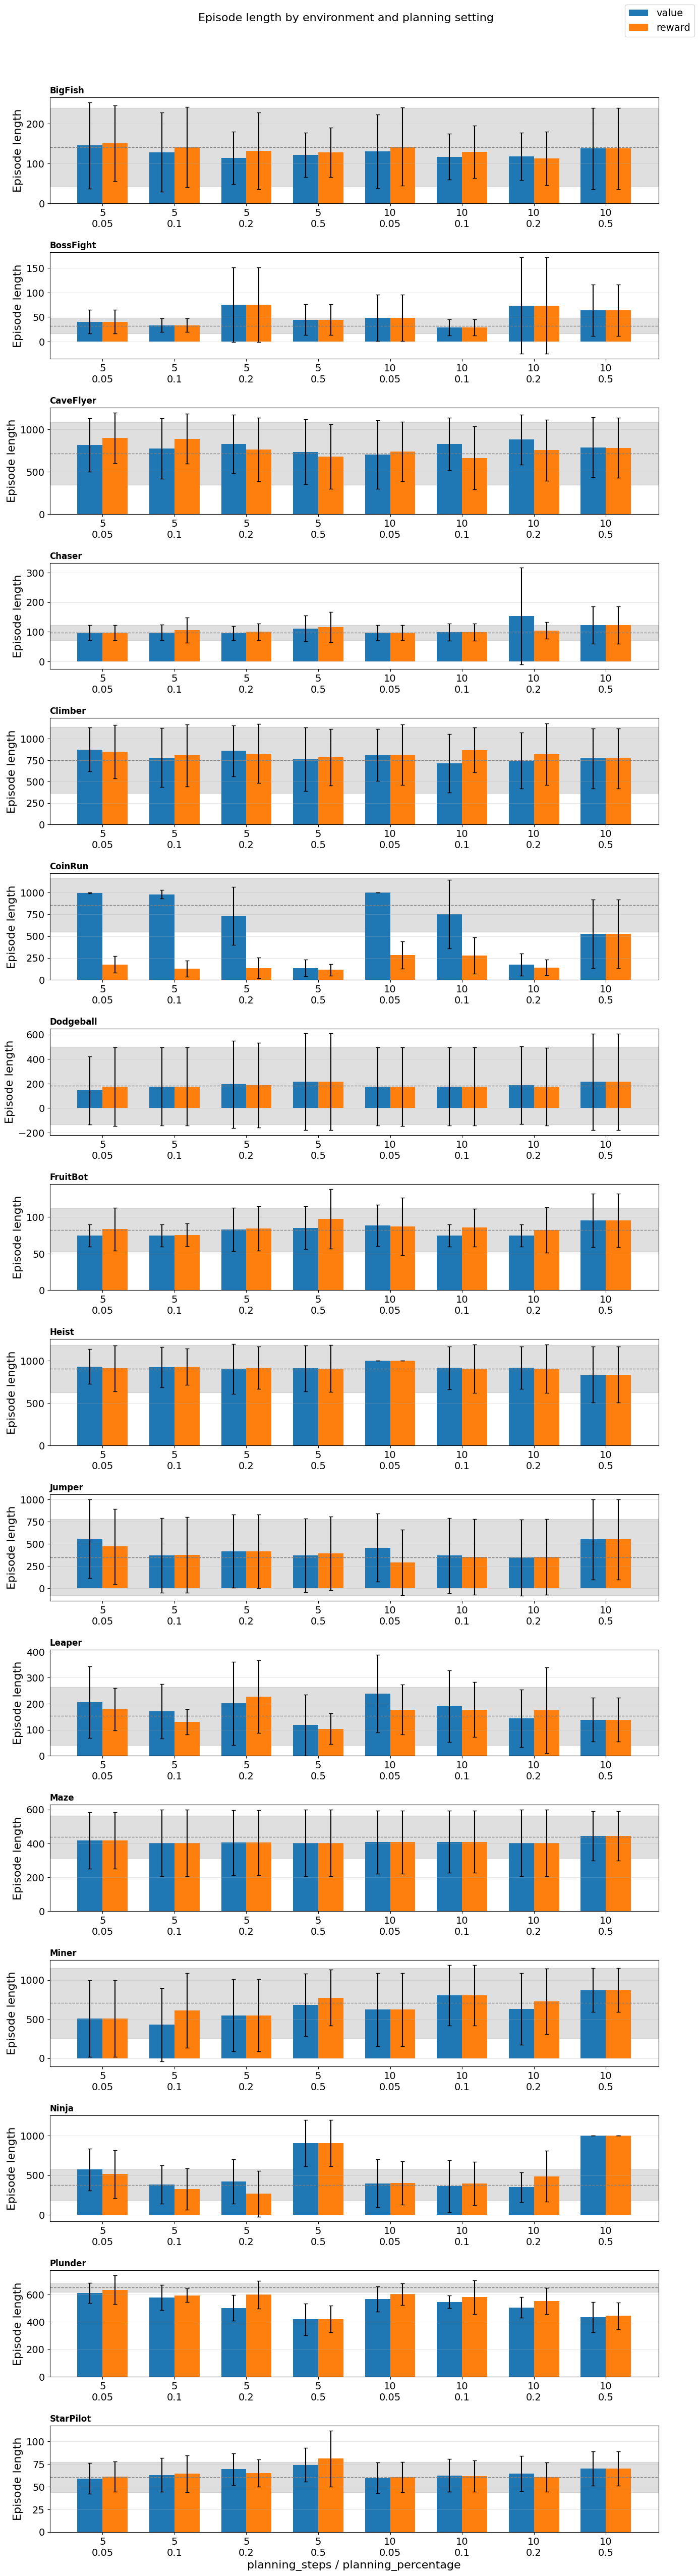

In [9]:
plot_metric(
    planning_df,
    baseline_df,
    value_col="episode_length_mean_all",
    std_col="episode_length_std_all",
    ylabel="Episode length",
    title="Episode length by environment and planning setting",
)

### Reward

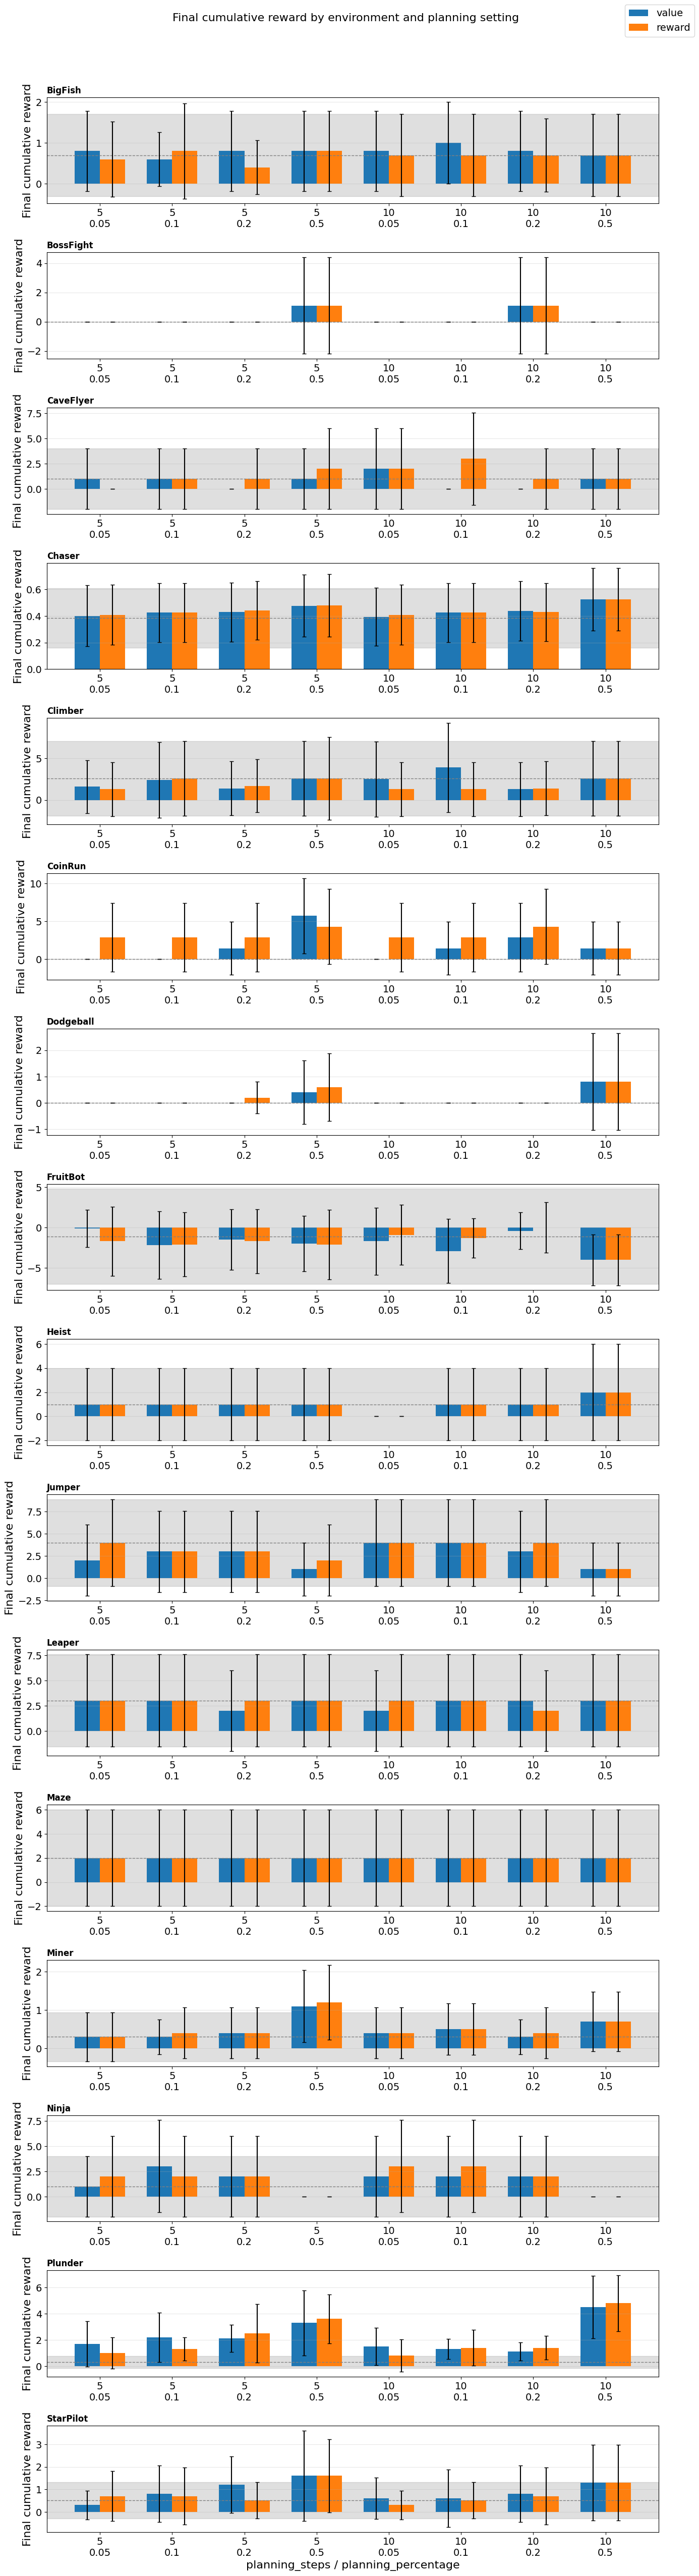

In [8]:
plot_metric(
    planning_df,
    baseline_df,
    value_col="reward_mean_all",
    std_col="reward_std_all",
    ylabel="Final cumulative reward",
    title="Final cumulative reward by environment and planning setting",
)

### Reward per step

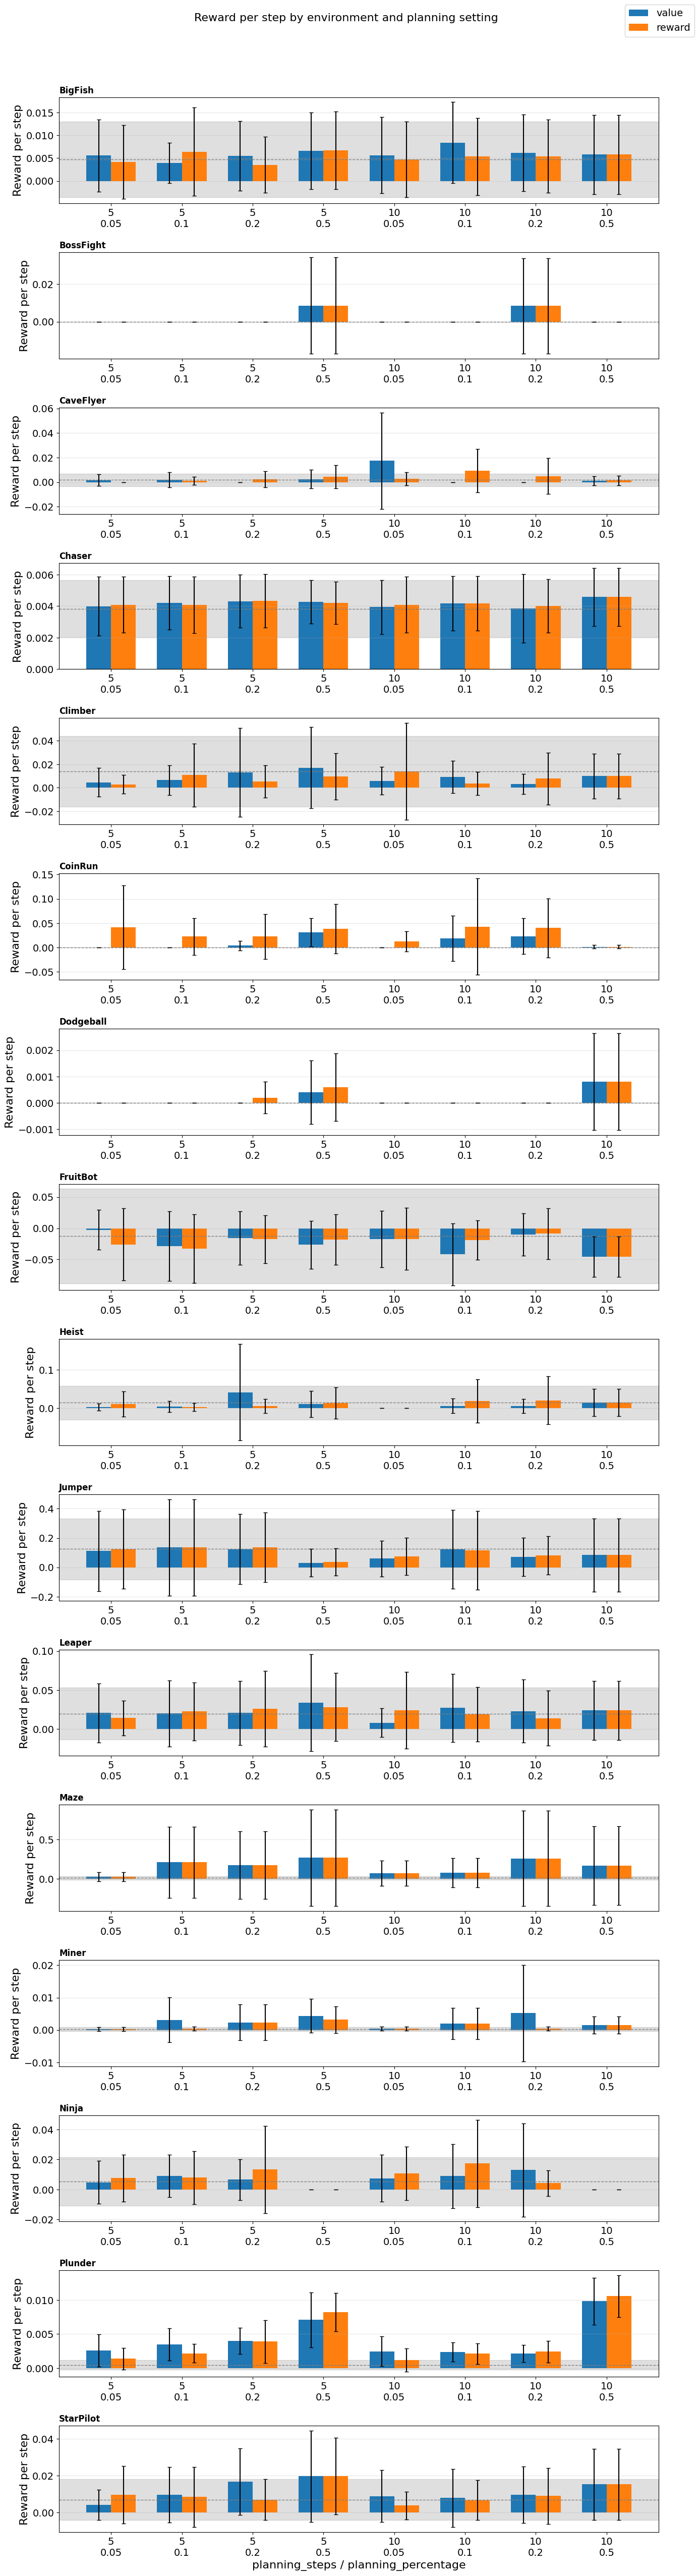

In [9]:
plot_metric(
    planning_df,
    baseline_df,
    value_col="reward_per_step_mean",
    std_col="reward_per_step_std",
    ylabel="Reward per step",
    title="Reward per step by environment and planning setting",
)

# Atari

In [2]:
# Load your CSV
df = pd.read_csv("/Users/Student/wm_inference_diffusion/src/pruned_sweep_results.csv")

# Ensure numeric conversion (to handle missing values gracefully)
for col in [
    "planning_steps", "threshold", "inner_steps",
    "reward_mean", "reward_std",
    "ep_length_mean", "ep_length_std",
    "num_planning_steps_mean", "num_planning_steps_std",
    "meta_depth_1_mean", "meta_depth_1_std",
    "meta_depth_2_mean", "meta_depth_2_std",
    "meta_depth_3_mean", "meta_depth_3_std",
    "meta_depth_4_mean", "meta_depth_4_std",
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- Baseline (reward, 0 steps, threshold=2.0, inner=0) ---
baseline_row = df[
    (df["mode"] == "reward") &
    (df["planning_steps"] == 0) &
    (df["threshold"] == 2.0) &
    (df["inner_steps"] == 0)
].iloc[0]

# Collect all baseline values
baseline = {
    "reward_mean": baseline_row["reward_mean"],
    "reward_std": baseline_row["reward_std"],
    "ep_length_mean": baseline_row["ep_length_mean"],
    "ep_length_std": baseline_row["ep_length_std"],
    "num_planning_steps_mean": baseline_row["num_planning_steps_mean"],
    "num_planning_steps_std": baseline_row["num_planning_steps_std"],
    "meta_depth_1_mean": baseline_row["meta_depth_1_mean"],
    "meta_depth_1_std": baseline_row["meta_depth_1_std"],
    "meta_depth_2_mean": baseline_row["meta_depth_2_mean"],
    "meta_depth_2_std": baseline_row["meta_depth_2_std"],
    "meta_depth_3_mean": baseline_row["meta_depth_3_mean"],
    "meta_depth_3_std": baseline_row["meta_depth_3_std"],
    "meta_depth_4_mean": baseline_row["meta_depth_4_mean"],
    "meta_depth_4_std": baseline_row["meta_depth_4_std"],
}

print("Baseline values:")
for k, v in baseline.items():
    print(f"  {k}: {v}")

Baseline values:
  reward_mean: 87.0
  reward_std: 5.656854249492381
  ep_length_mean: 1517.0
  ep_length_std: 140.50148279170105
  num_planning_steps_mean: 0.0
  num_planning_steps_std: 0.0
  meta_depth_1_mean: 0.0
  meta_depth_1_std: 0.0
  meta_depth_2_mean: 0.0
  meta_depth_2_std: 0.0
  meta_depth_3_mean: 0.0
  meta_depth_3_std: 0.0
  meta_depth_4_mean: 0.0
  meta_depth_4_std: 0.0


# Cumulative Reward

In [3]:
def plot_comparison(title, subset_df, x_col, xlabel):
    """
    Plot reward vs value mode for a given subset of df
    """
    plt.figure(figsize=(8, 5))
    for mode, color in [("reward", "green"), ("value", "blue")]:
        mode_df = subset_df[subset_df["mode"] == mode].dropna(subset=["mean", "std"])
        if mode_df.empty:
            continue
        x = mode_df[x_col].values
        y = mode_df["reward_mean"].values
        yerr = mode_df["reward_std"].values
        plt.plot(x, y, label=f"{mode.title()} Planning", color=color, marker="o")
        plt.fill_between(x, y - yerr, y + yerr, alpha=0.2, color=color)

    # baseline line
    plt.axhline(y=baseline["reward_mean"], linestyle="--", color="gray", label="No Planning")
    plt.fill_between([min(subset_df[x_col]), max(subset_df[x_col])],
                     baseline["reward_mean"] - baseline["reward_std"], baseline["reward_mean"] + baseline["reward_std"],
                     color="red", alpha=0.2)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Cumulative Reward")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_subset(ax, subset, x_col, xlabel, title=None, ylabel=False):
    for mode, color in [("reward", "green"), ("value", "blue")]:
        sub = subset[(subset["mode"] == mode)].dropna(subset=["reward_mean"])
        if sub.empty:
            continue
        x = sub[x_col].values
        y = sub["reward_mean"].values
        yerr = sub["reward_std"].values
        ax.plot(x, y, label=f"{mode.title()} Planning", color=color, marker="o")
        ax.fill_between(x, y-yerr, y+yerr, alpha=0.2, color=color)

    # baseline line
    ax.axhline(y=baseline["reward_mean"], linestyle="--", color="red", label="No Planning")
    ax.fill_between([subset[x_col].min(), subset[x_col].max()],
                    baseline["reward_mean"] - baseline["reward_std"], baseline["reward_mean"] + baseline["reward_std"],
                    color="red", alpha=0.2)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel("Cumulative Reward")  # only leftmost column
    ax.grid(True)
    ax.set_ylim(65,100)

    # ensure yticks are visible on all subplots
    ax.tick_params(axis='y', which='both', labelleft=True)


def plot_grid(subsets, x_col, xlabel, titles=None, ncols=3, sharey=True):
    import math
    n = len(subsets)
    nrows = math.ceil(n / ncols)

    fig = plt.figure(figsize=(6*ncols, 5*nrows))
    gs = fig.add_gridspec(nrows, ncols)

    axes = []
    for i, subset in enumerate(subsets):
        row, col = divmod(i, ncols)

        # --- If last row is incomplete, recenter it ---
        if row == nrows - 1 and (n % ncols != 0):
            n_last = n % ncols
            start_col = (ncols - n_last) // 2
            col = start_col + col % n_last  # shift placement

        ax = fig.add_subplot(gs[row, col], sharey=axes[0] if (axes and sharey) else None)
        axes.append(ax)

        # Decide if this subplot should have a ylabel (first column actually drawn)
        if row == nrows - 1 and (n % ncols != 0):
            # recompute start_col for last row
            start_col = (ncols - (n % ncols)) // 2
            ylabel = (col == start_col)
        else:
            ylabel = (col == 0)

        plot_subset(
            ax,
            subset,
            x_col,
            xlabel,
            title=titles[i] if titles else "",
            ylabel=ylabel
        )

    # --- Hide unused axes (if any exist in the grid) ---
    total_axes = nrows * ncols
    for j in range(n, total_axes):
        fig.add_subplot(gs[j // ncols, j % ncols]).axis("off")

    # --- Shared legend ---
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center", ncol=3, bbox_to_anchor=(0.5, -0.05))

    fig.tight_layout()
    plt.show()

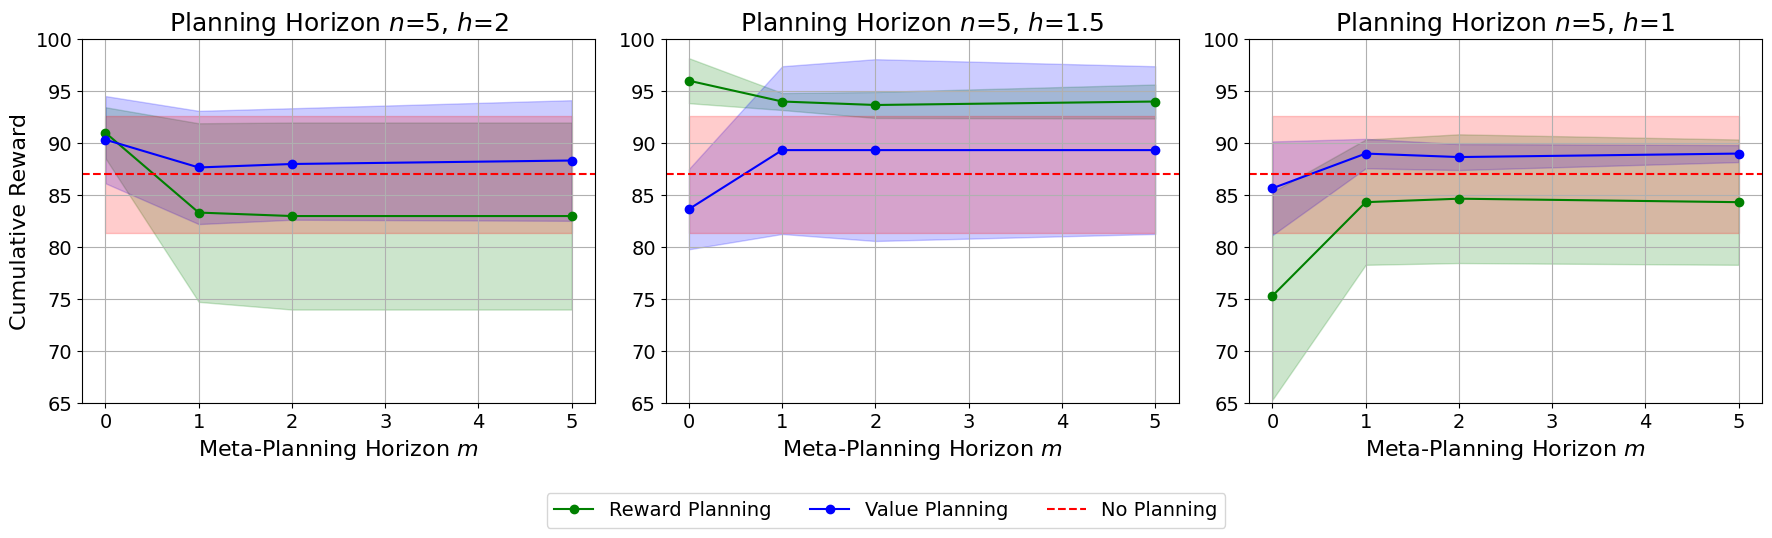

In [4]:
subsets = [
    df[(df["threshold"]==ent) & (df["planning_steps"]==5)]
    for ent in [2, 1.5, 1]
]
titles = [f"Planning Horizon $n$=5, $h$={ent}" for ent in [2, 1.5, 1]]
plot_grid(subsets, "inner_steps", "Meta-Planning Horizon $m$", titles=titles)

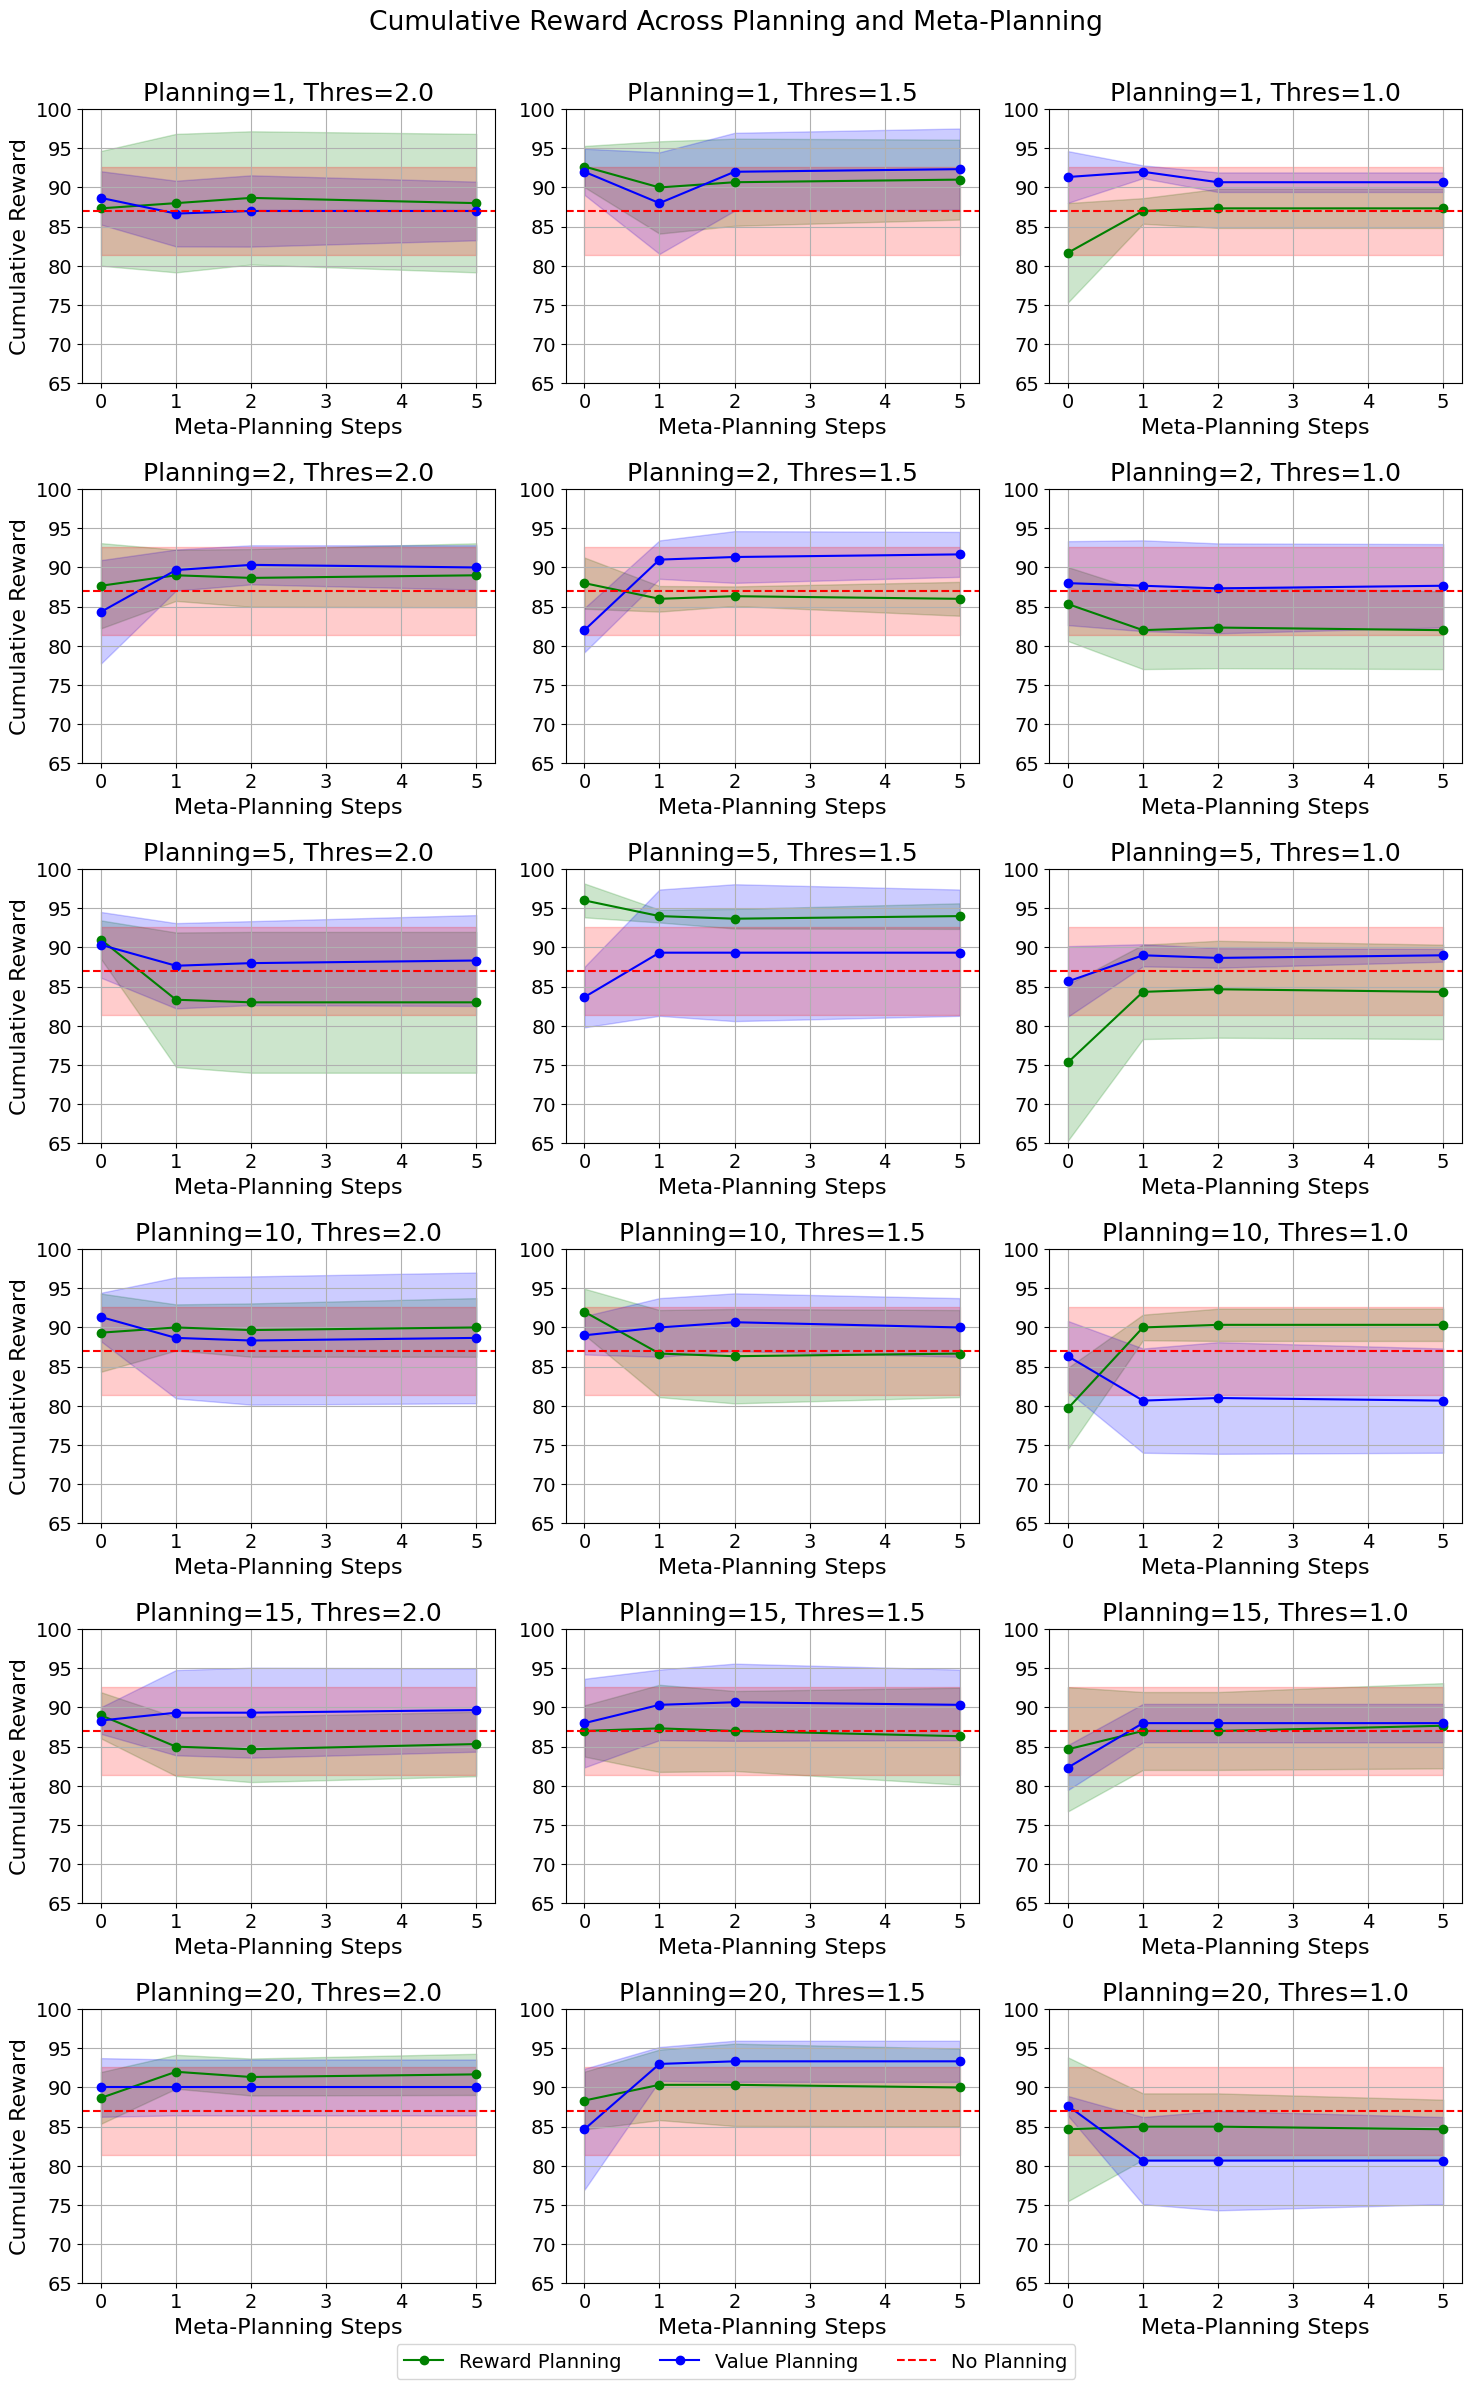

In [5]:
planning_vals = [1, 2, 5, 10, 15, 20]
thresholds = [2.0, 1.5, 1.0]

# Build subsets and titles
subsets = []
titles = []
for p in planning_vals:
    for thr in thresholds:
        subsets.append(df[(df["planning_steps"] == p) & (df["threshold"] == thr)])
        titles.append(f"Planning={p}, Thres={thr}")

# Plot in grid: rows = planning_vals, cols = thresholds
nrows = len(planning_vals)
ncols = len(thresholds)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows), sharey=True)

for i, (subset, title) in enumerate(zip(subsets, titles)):
    r, c = divmod(i, ncols)
    plot_subset(
        axes[r, c],
        subset,
        x_col="inner_steps",
        xlabel="Meta-Planning Steps",
        title=title,
        ylabel=(c == 0)  # only leftmost column
    )

# Shared legend
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center", ncol=3, bbox_to_anchor=(0.5, 0))

plt.tight_layout(rect=[0,0,1,0.96])
fig.suptitle("Cumulative Reward Across Planning and Meta-Planning")
plt.show()

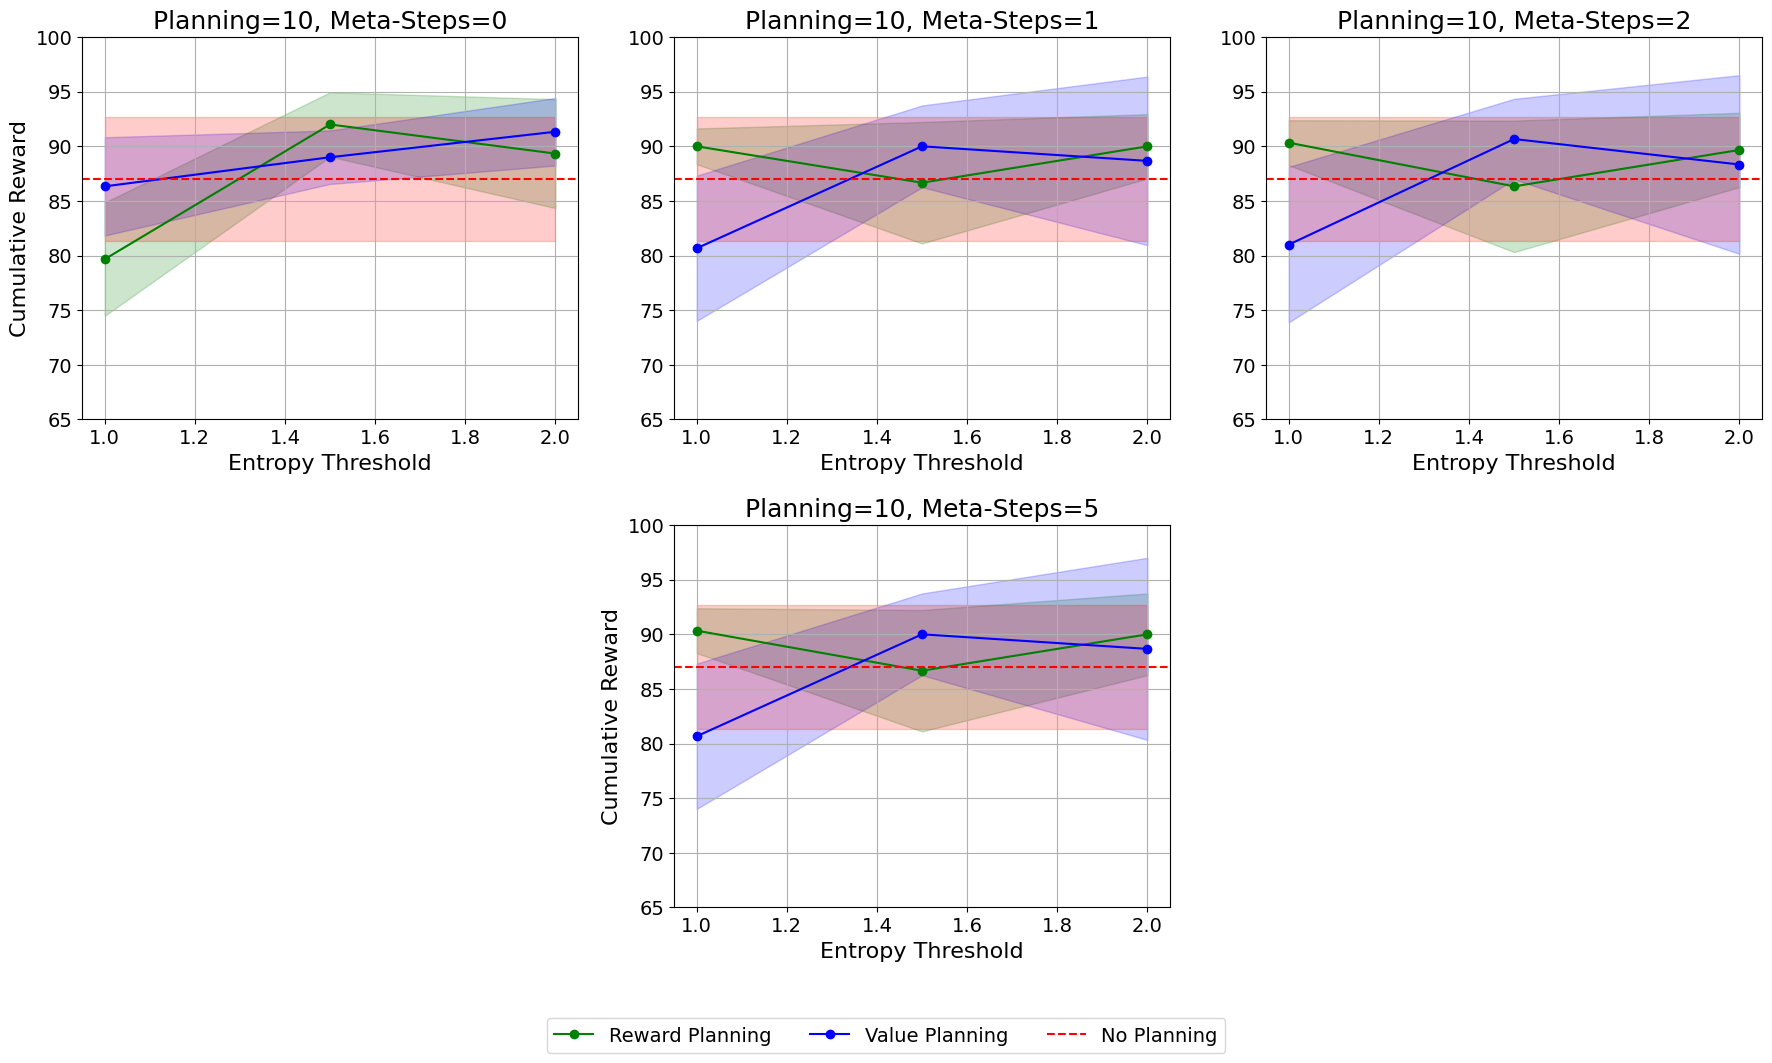

In [6]:
subsets = [
    df[(df["planning_steps"]==10) & (df["inner_steps"]==inner)]
    for inner in [0,1,2,5]
]
titles = [f"Planning=10, Meta-Steps={i}" for i in [0,1,2,5]]
plot_grid(subsets, "threshold", "Entropy Threshold", titles)

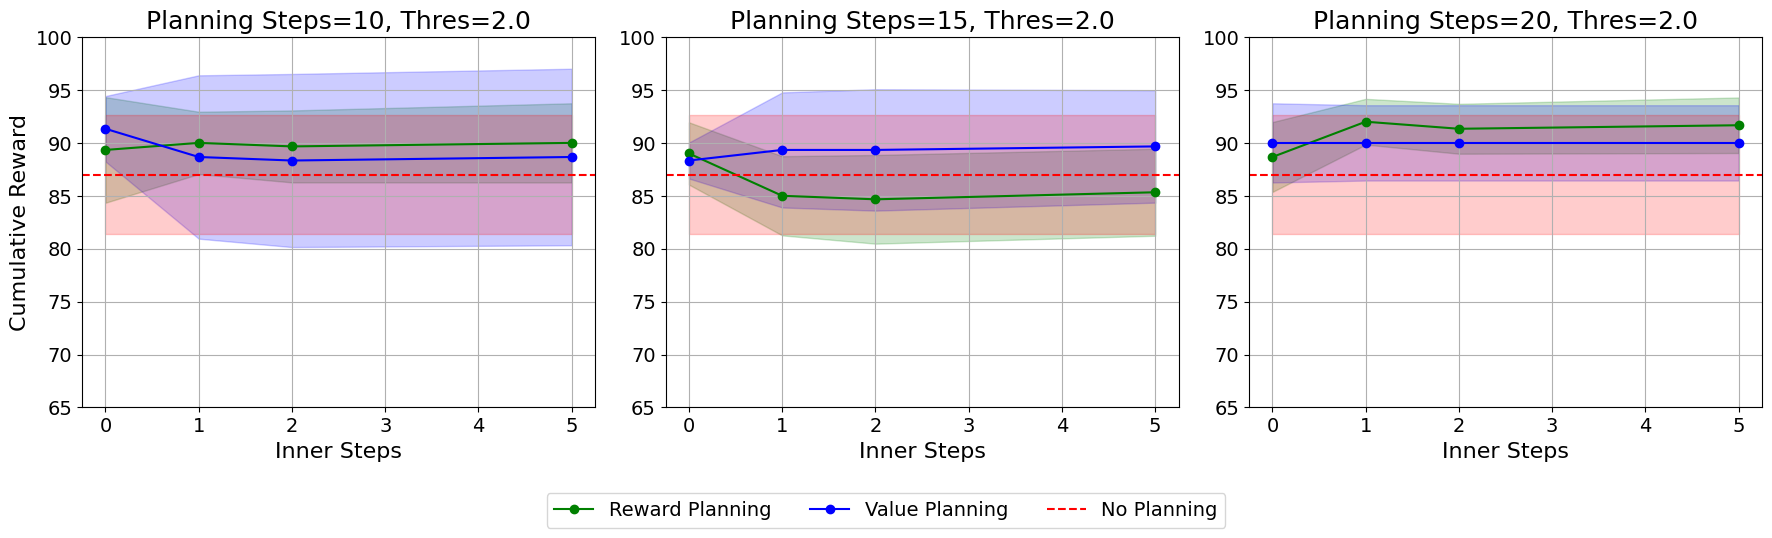

In [7]:
subsets = [
    df[(df["planning_steps"]==ps) & (df["threshold"]==2.0)]
    for ps in [10,15,20]
]
titles = [f"Planning Steps={ps}, Thres=2.0" for ps in [10,15,20]]
plot_grid(subsets, "inner_steps", "Inner Steps", titles)

# Episode Length

In [8]:
def plot_comparison_ep(title, subset_df, x_col, xlabel):
    """
    Plot episode length vs value mode for a given subset of df
    """
    plt.figure(figsize=(8, 5))
    for mode, color in [("reward", "green"), ("value", "blue")]:
        mode_df = subset_df[subset_df["mode"] == mode].dropna(subset=["ep_length_mean", "ep_length_std"])
        if mode_df.empty:
            continue
        x = mode_df[x_col].values
        y = mode_df["ep_length_mean"].values
        yerr = mode_df["ep_length_std"].values
        plt.plot(x, y, label=f"{mode.title()} Planning", color=color, marker="o")
        plt.fill_between(x, y - yerr, y + yerr, alpha=0.2, color=color)

    # baseline line
    plt.axhline(y=baseline["ep_length_mean"], linestyle="--", color="gray", label="No Planning")
    plt.fill_between([min(subset_df[x_col]), max(subset_df[x_col])],
                     baseline["ep_length_mean"] - baseline["ep_length_std"], baseline["ep_length_mean"] + baseline["ep_length_std"],
                     color="gray", alpha=0.2)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Episode Length")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_subset_ep(ax, subset, x_col, xlabel, title=None, ylabel=False):
    for mode, color in [("reward", "green"), ("value", "blue")]:
        sub = subset[(subset["mode"] == mode)].dropna(subset=["ep_length_mean"])
        if sub.empty:
            continue
        x = sub[x_col].values
        y = sub["ep_length_mean"].values
        yerr = sub["ep_length_std"].values
        ax.plot(x, y, label=f"{mode.title()} Planning", color=color, marker="o")
        ax.fill_between(x, y-yerr, y+yerr, alpha=0.2, color=color)

    # baseline line
    ax.axhline(y=baseline["ep_length_mean"], linestyle="--", color="gray", label="No Planning")
    ax.fill_between([subset[x_col].min(), subset[x_col].max()],
                    baseline["ep_length_mean"] - baseline["ep_length_std"], baseline["ep_length_mean"] + baseline["ep_length_std"],
                    color="gray", alpha=0.2)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel("Episode Length")  # only leftmost column
    ax.grid(True)
    ax.tick_params(axis='y', which='both', labelleft=True)


def plot_grid_ep(subsets, x_col, xlabel, titles=None, ncols=3):
    n = len(subsets)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), sharey=True)
    axes = axes.flatten() if n > 1 else [axes]

    for i, subset in enumerate(subsets):
        col = i % ncols
        plot_subset_ep(
            axes[i],
            subset,
            x_col,
            xlabel,
            title=titles[i] if titles else "",
            ylabel=(col == 0)
        )

    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center", ncol=3, bbox_to_anchor=(0.5, -0.05))
    fig.tight_layout()
    plt.show()

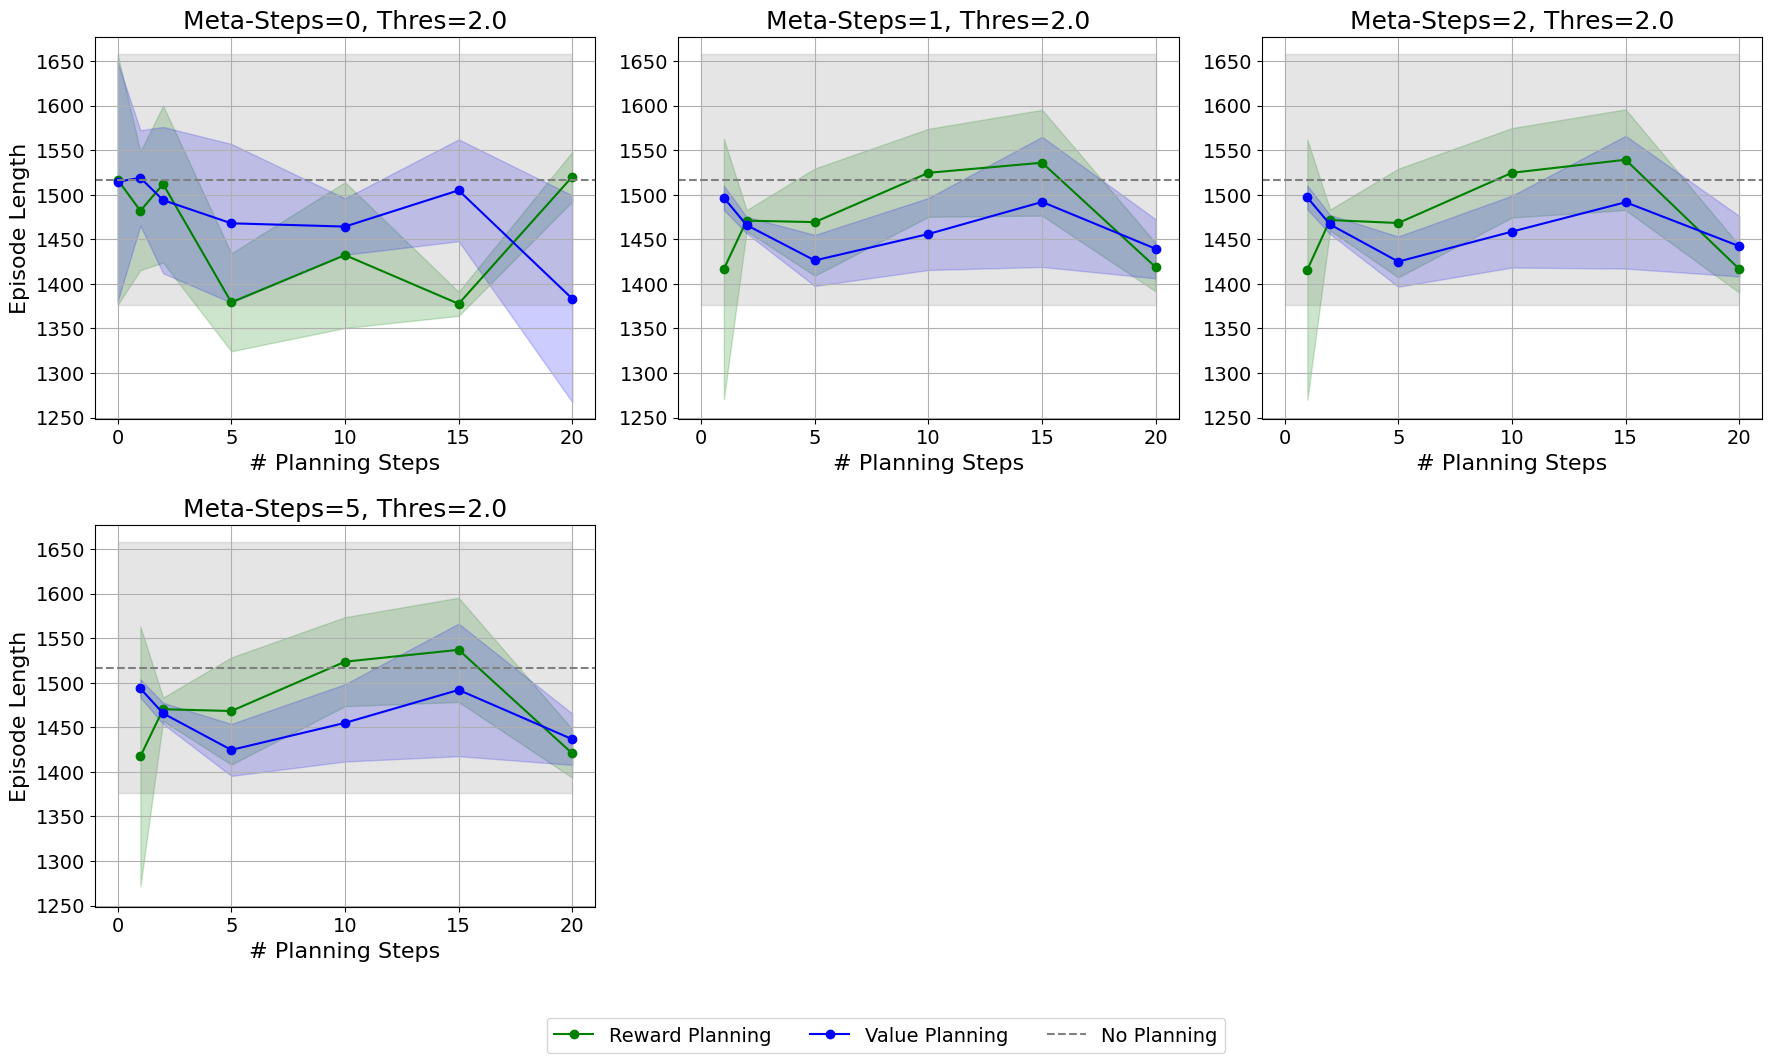

In [9]:
subsets = [
    df[(df["threshold"]==2.0) & (df["inner_steps"]==inner)]
    for inner in [0,1,2,5]
]
titles = [f"Meta-Steps={i}, Thres=2.0" for i in [0,1,2,5]]
plot_grid_ep(subsets, "planning_steps", "# Planning Steps", titles=titles)

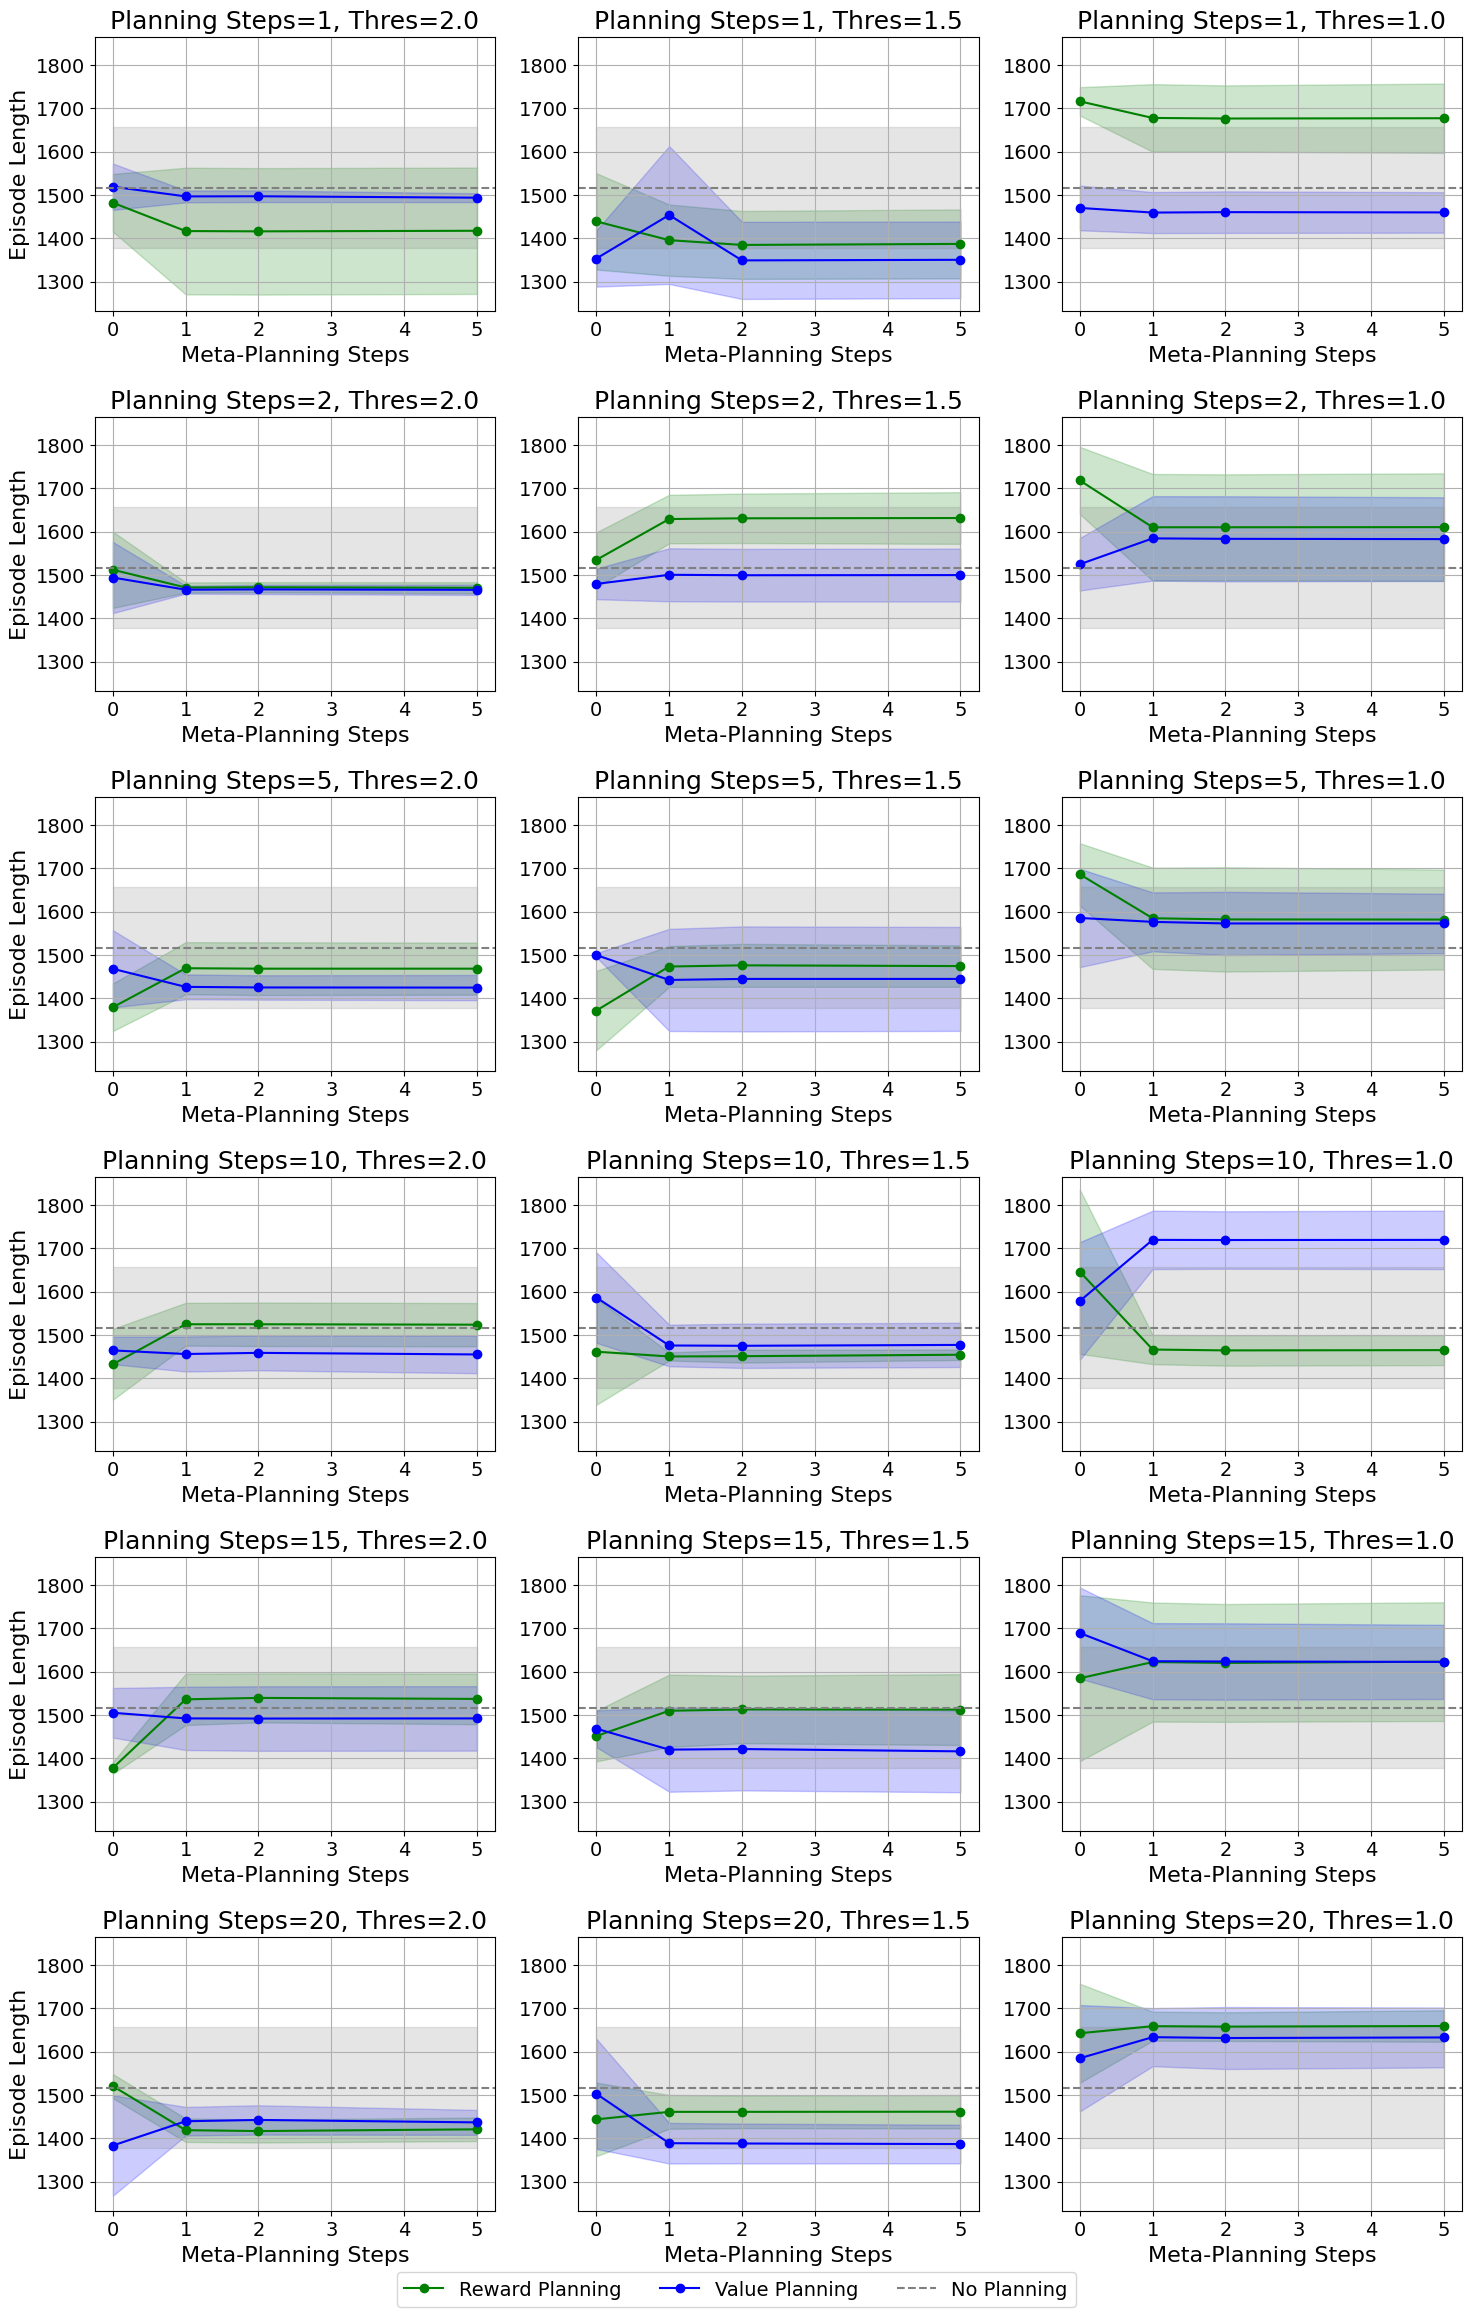

In [10]:
planning_vals = [1, 2, 5, 10, 15, 20]
thresholds = [2.0, 1.5, 1.0]

# Build subsets and titles
subsets = []
titles = []
for p in planning_vals:
    for thr in thresholds:
        subsets.append(df[(df["planning_steps"] == p) & (df["threshold"] == thr)])
        titles.append(f"Planning Steps={p}, Thres={thr}")

# Plot in grid: rows = planning_vals, cols = thresholds
nrows = len(planning_vals)
ncols = len(thresholds)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows), sharey=True)

for i, (subset, title) in enumerate(zip(subsets, titles)):
    r, c = divmod(i, ncols)
    plot_subset_ep(
        axes[r, c],
        subset,
        x_col="inner_steps",
        xlabel="Meta-Planning Steps",
        title=title,
        ylabel=(c == 0)  # only leftmost column
    )

# Shared legend
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center", ncol=3, bbox_to_anchor=(0.5, 0))

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

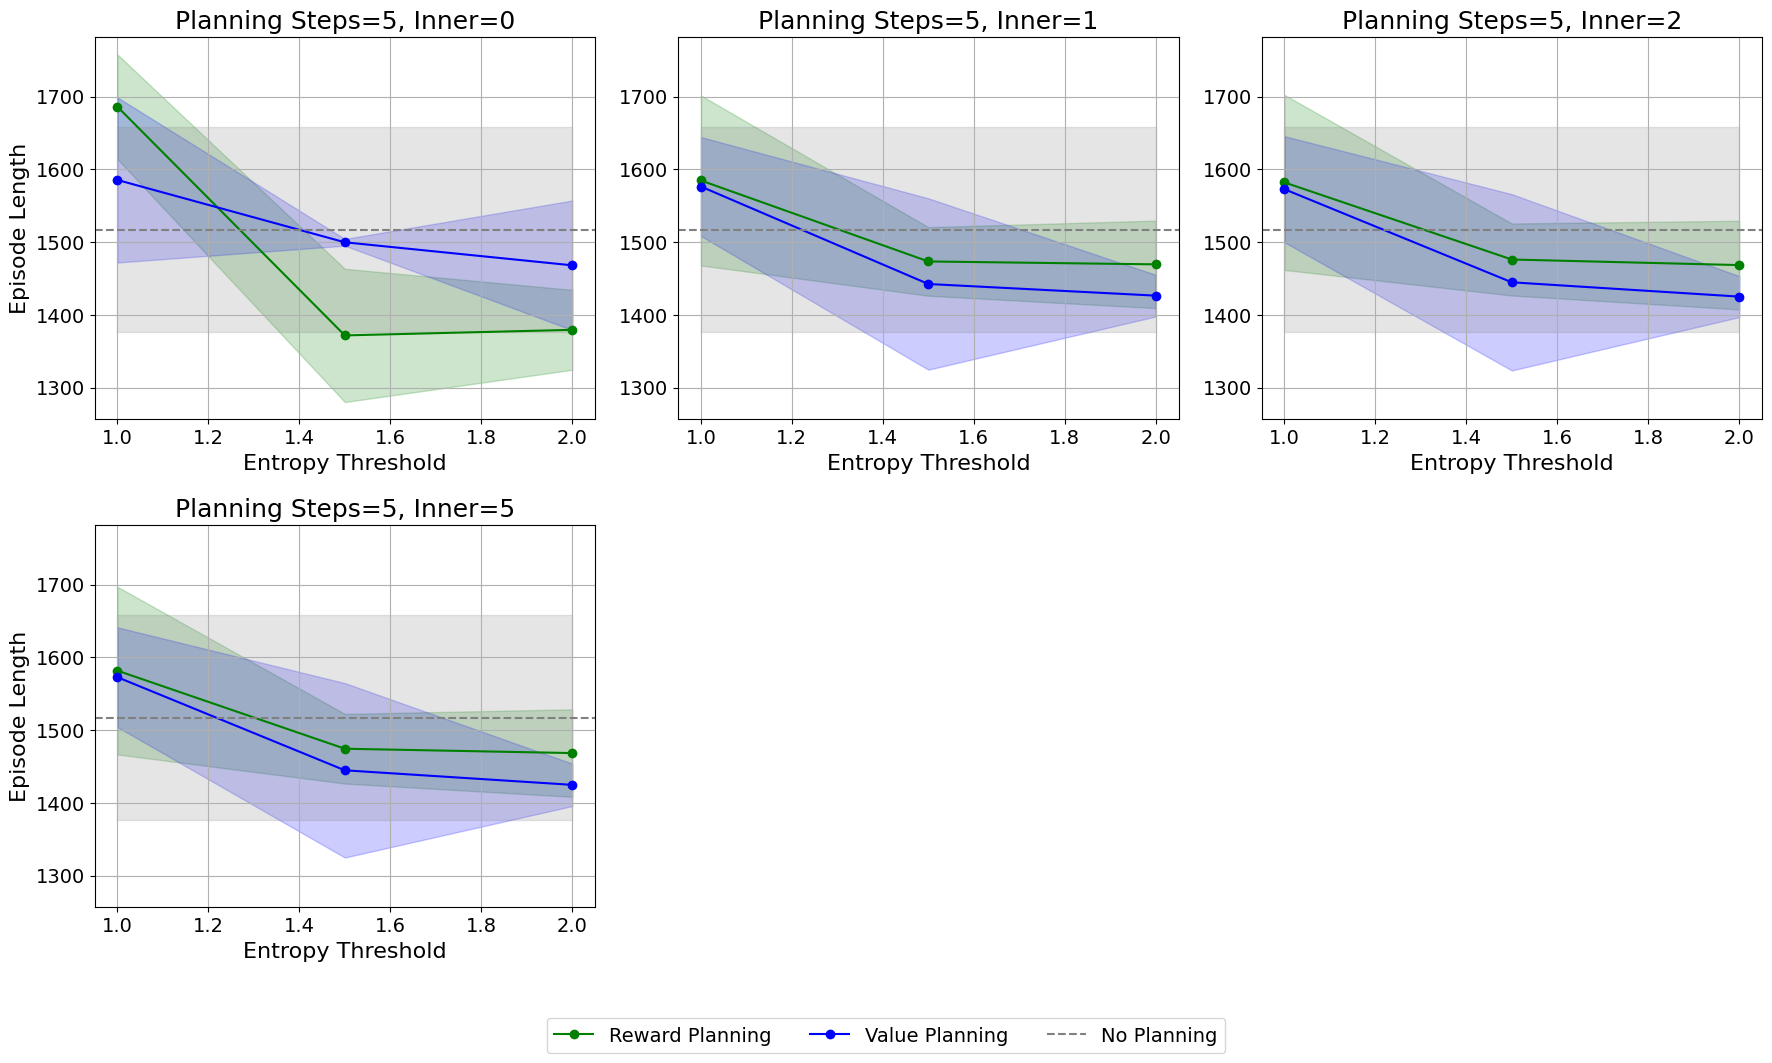

In [11]:
subsets = [
    df[(df["planning_steps"]==5) & (df["inner_steps"]==inner)]
    for inner in [0,1,2,5]
]
titles = [f"Planning Steps=5, Inner={i}" for i in [0,1,2,5]]
plot_grid_ep(subsets, "threshold", "Entropy Threshold", titles=titles)

# Meta-Planning Depth

In [12]:
def plot_meta_depth_fraction(ax, subset, title=None, ylabel=False):
    meta_cols_mean = [
        "meta_depth_1_mean", "meta_depth_2_mean",
        "meta_depth_3_mean", "meta_depth_4_mean"
    ]
    meta_cols_std = [
        "meta_depth_1_std", "meta_depth_2_std",
        "meta_depth_3_std", "meta_depth_4_std"
    ]

    x = np.arange(len(meta_cols_mean) + 1)  # +1 for No meta-planning
    width = 0.25

    for i, (mode, color) in enumerate([("reward", "green"), ("value", "blue")]):
        sub = subset[subset["mode"] == mode]
        if sub.empty:
            continue

        # Take mean across runs
        A_means = sub[meta_cols_mean].mean().values
        A_stds  = sub[meta_cols_std].mean().values
        B_mean  = sub["num_planning_steps_mean"].mean()
        B_std   = sub["num_planning_steps_std"].mean()

        # Ratio and propagated std
        R_means = A_means / B_mean
        R_stds  = np.sqrt((A_stds / B_mean) ** 2 + (A_means * B_std / (B_mean**2)) ** 2)

        # No meta-planning = 1 - sum of fractions
        no_meta_mean = 1.0 - R_means.sum()
        no_meta_std  = np.sqrt(np.sum(R_stds**2))

        # Prepend to arrays
        R_means = np.insert(R_means, 0, no_meta_mean)
        R_stds  = np.insert(R_stds, 0, no_meta_std)

        # Bars with error bars
        bars = ax.bar(x + i*width, R_means, width, yerr=R_stds,
                      label=f"{mode.title()} Planning", color=color, alpha=0.8, capsize=4)

        # Annotate values
        for j, bar in enumerate(bars):
            height = bar.get_height()
            ax.annotate(f"{height:.2f}",
                        xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x + width/2)
    ax.set_xticklabels(["No Meta-\nplanning", "Depth 1", "Depth 2", "Depth 3", "Depth 4"])
    if ylabel:
        ax.set_ylabel("Fraction of # Planning Steps")
    if title:
        ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.5)


def plot_meta_depth_grid(subsets, titles=None, ncols=3, sharey=True):
    n = len(subsets)
    nrows = math.ceil(n / ncols)

    fig = plt.figure(figsize=(6*ncols, 5*nrows))
    gs = fig.add_gridspec(nrows, ncols)

    axes = []
    row_first_axes = {}

    for i, subset in enumerate(subsets):
        row, col = divmod(i, ncols)

        # --- If last row is incomplete, recenter it ---
        if row == nrows - 1 and (n % ncols != 0):
            n_last = n % ncols
            start_col = (ncols - n_last) // 2
            col = start_col + col % n_last

        ax = fig.add_subplot(gs[row, col])
        axes.append(ax)

        # sharey within each row
        if row not in row_first_axes:
            row_first_axes[row] = ax
        else:
            ax.sharey(row_first_axes[row])

        plot_meta_depth_fraction(
            ax,
            subset,
            title=titles[i] if titles else "",
            ylabel=(ax is row_first_axes[row])  # only first axis in this row
        )

    # --- Shared legend with wrapped label ---
    handles, labels = axes[0].get_legend_handles_labels()
    labels = ["No\nmeta-planning" if l == "No meta-planning" else l for l in labels]
    fig.legend(handles, labels, loc="center", ncol=2, bbox_to_anchor=(0.5, -0.01))

    # fig.suptitle(r"Planning Horizon $n$=5")
    fig.tight_layout()
    plt.show()

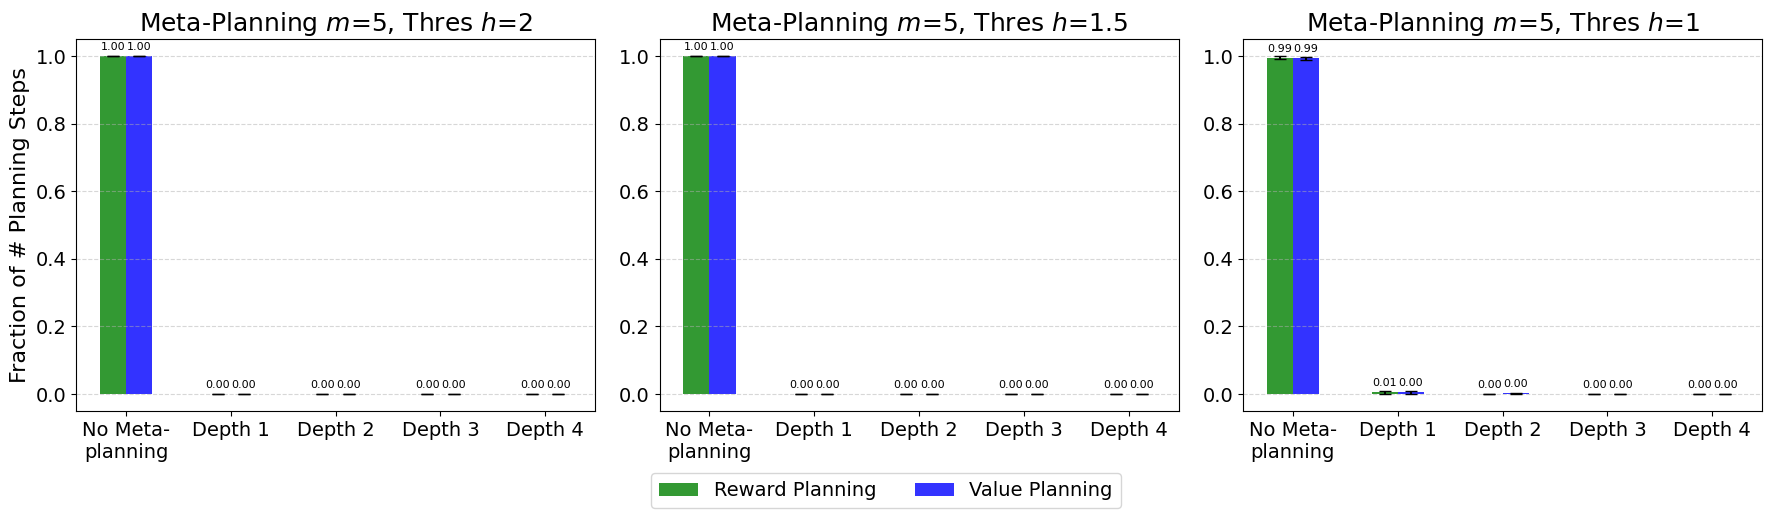

In [13]:
subsets = [
    df[(df["planning_steps"] == 5) &   # <-- fix planning_steps
       (df["threshold"] == thresh) &
       (df["inner_steps"] == 5)]
    for thresh in [2, 1.5, 1]
]
titles = [f"Meta-Planning $m$={5}, Thres $h$={thresh}"
          for thresh in [2, 1.5, 1]]

plot_meta_depth_grid(subsets, titles=titles)

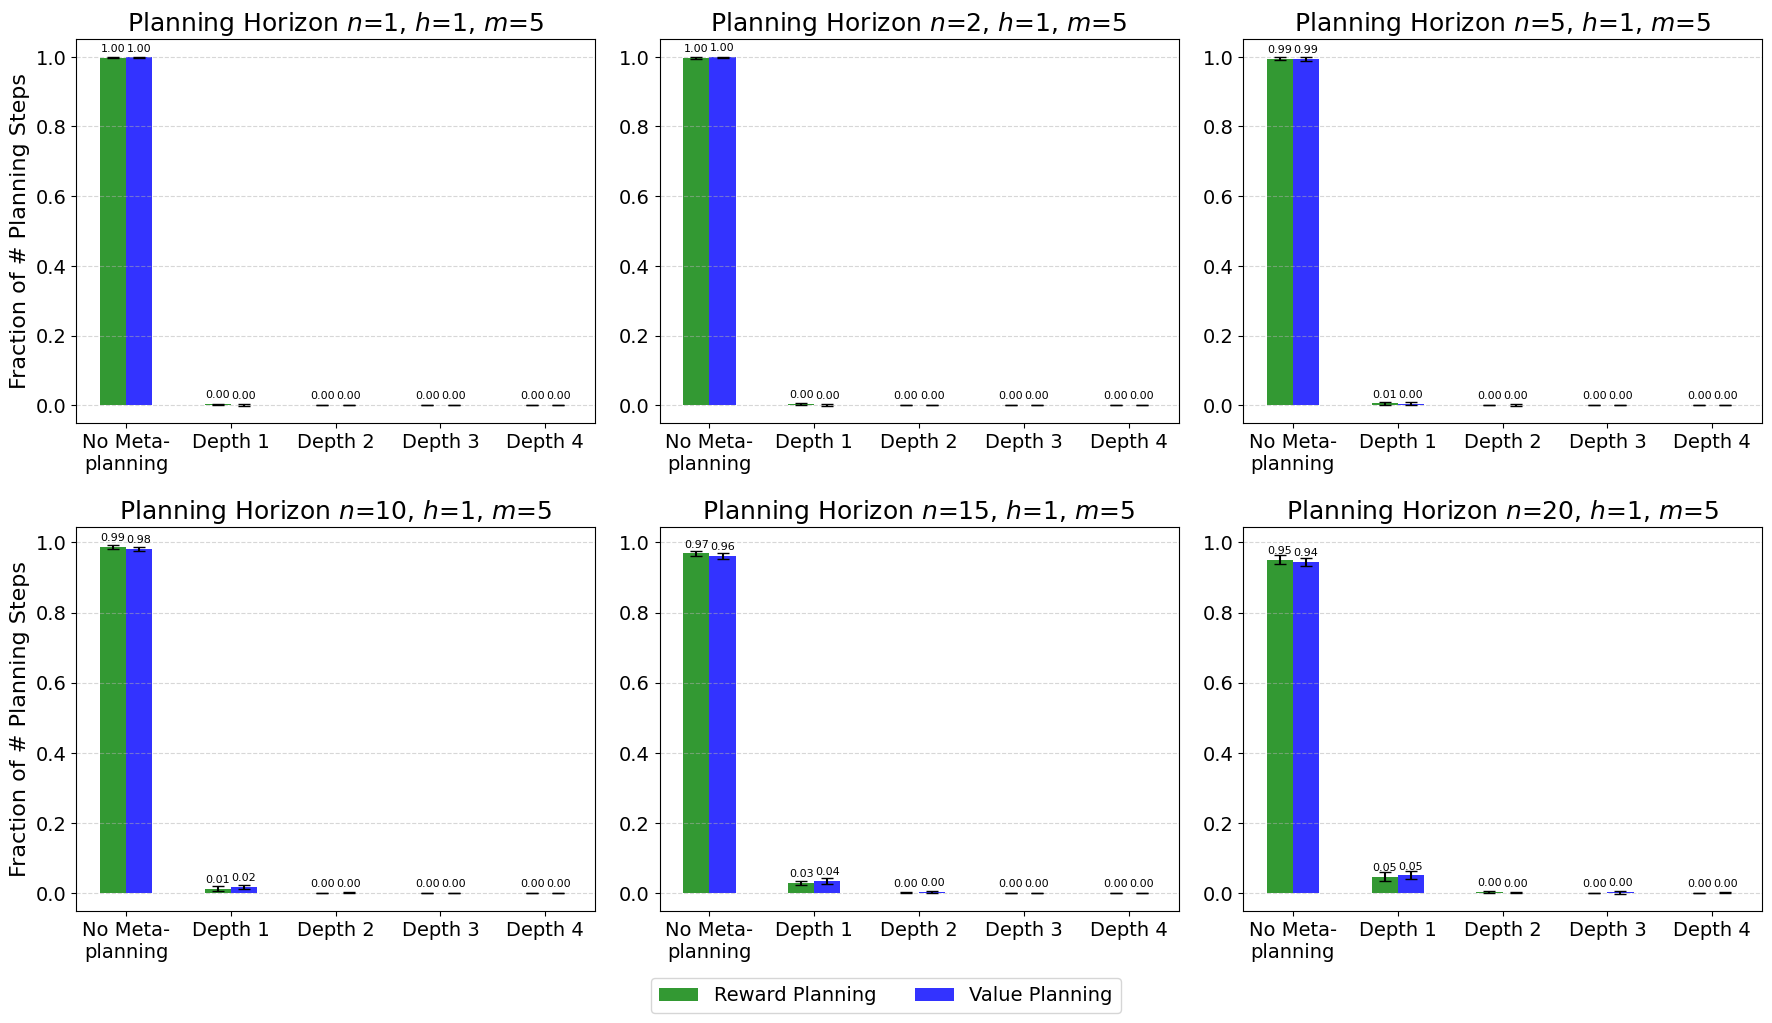

In [14]:
subsets = [
    df[(df["planning_steps"] == plan) &   # <-- fix planning_steps
       (df["threshold"] == 1) &
       (df["inner_steps"] == 5)]
    for plan in [1,2,5,10,15,20]
]
titles = [f"Planning Horizon $n$={plan}, $h$={1}, $m$={5}"
          for plan in [1,2,5,10,15,20]]

plot_meta_depth_grid(subsets, titles=titles)

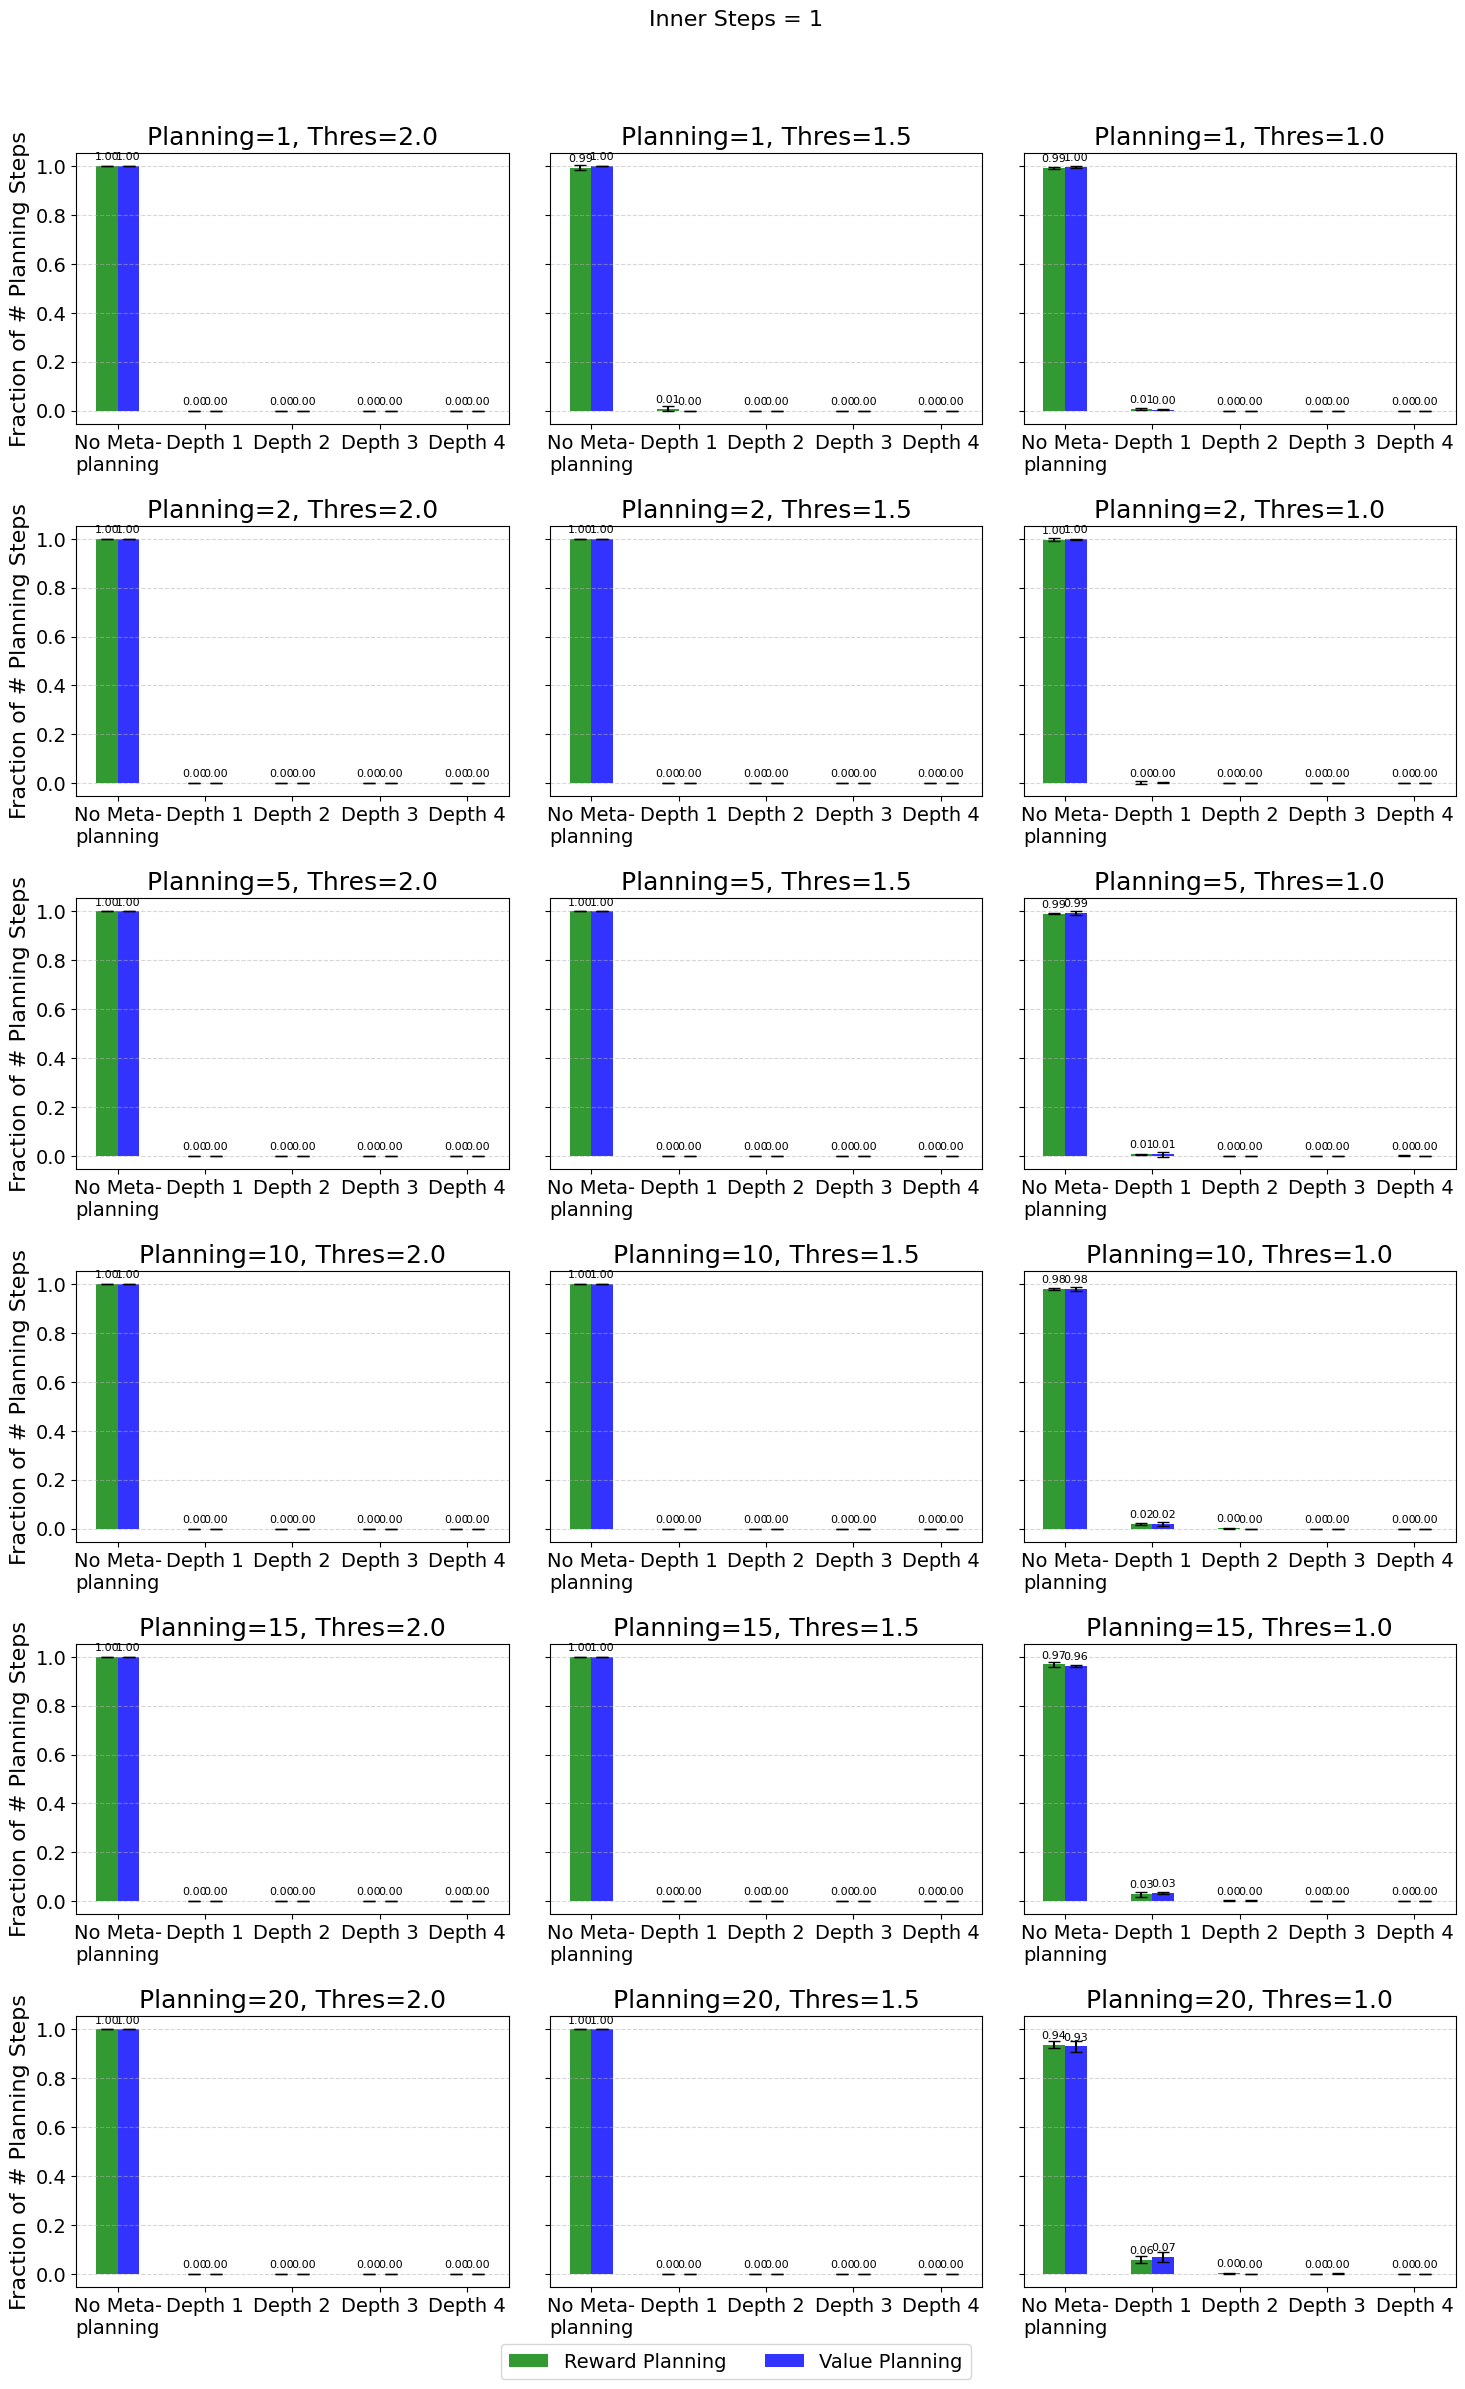

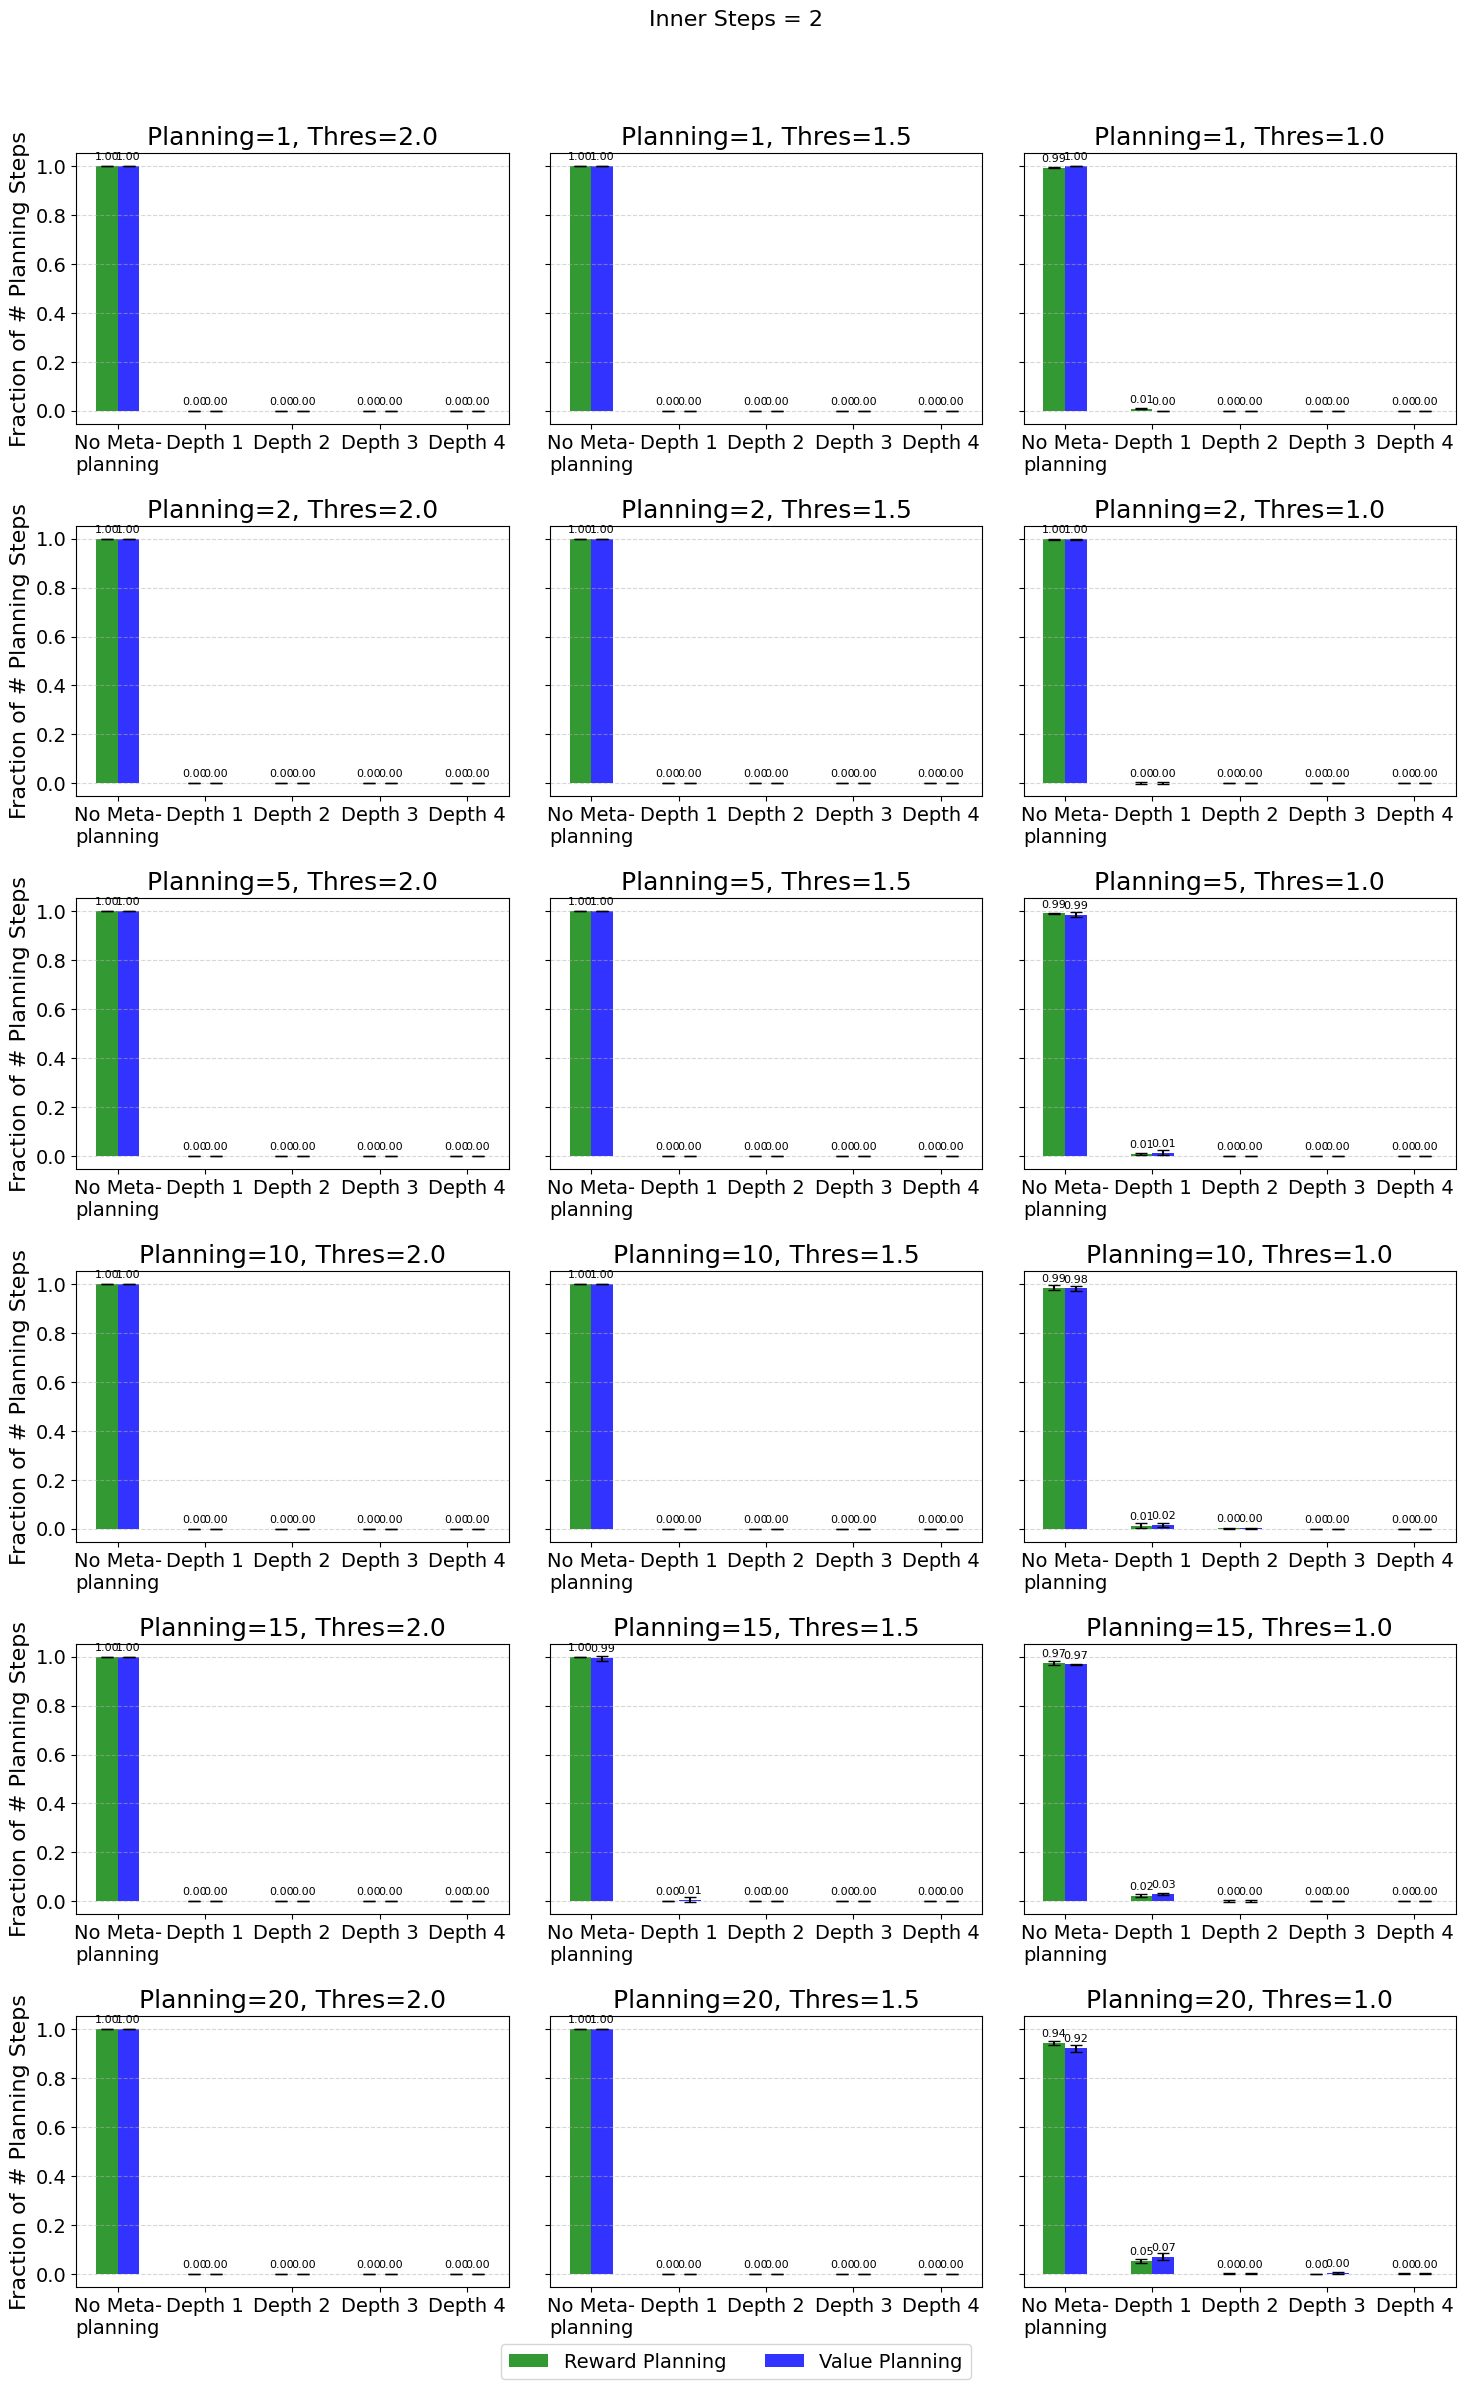

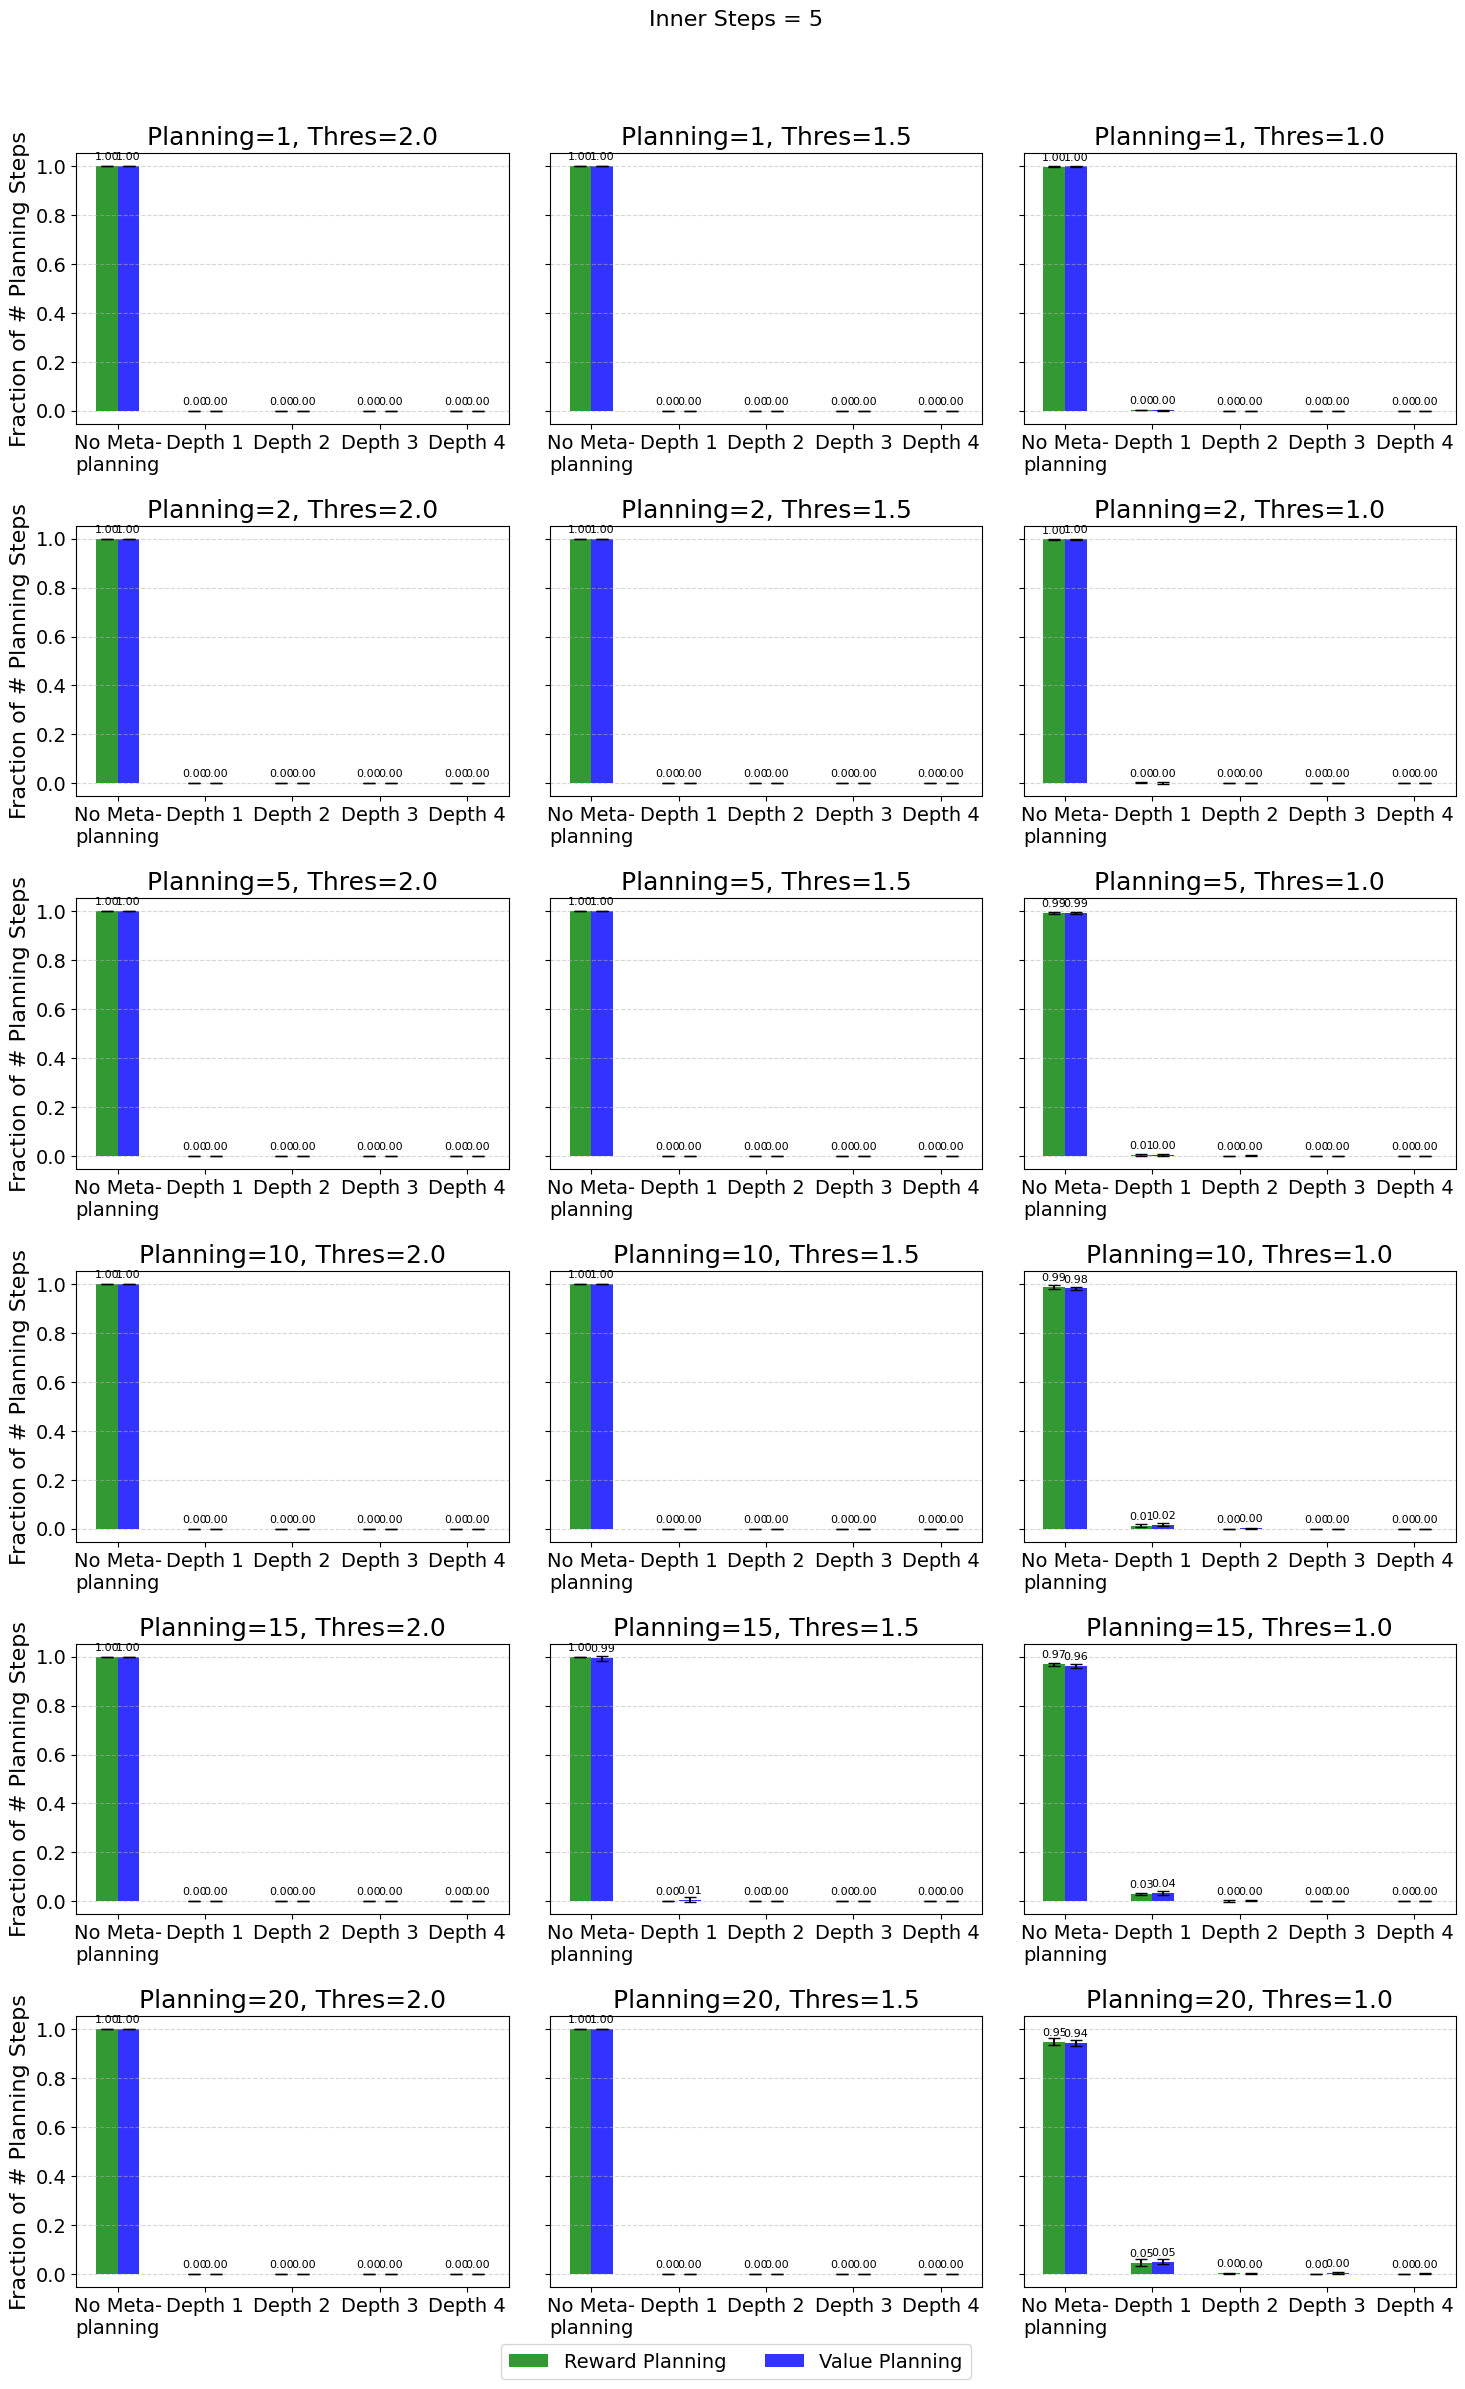

In [15]:
planning_vals = [1, 2, 5, 10, 15, 20]
thresholds = [2.0, 1.5, 1.0]
inner_steps_vals = [1, 2, 5]

for inner in inner_steps_vals:
    subsets = []
    titles = []
    for p in planning_vals:
        for thr in thresholds:
            subset = df[(df["planning_steps"] == p) & 
                        (df["threshold"] == thr) & 
                        (df["inner_steps"] == inner)]
            subsets.append(subset)
            titles.append(f"Planning={p}, Thres={thr}")

    # Grid: rows = planning_steps, cols = thresholds
    nrows = len(planning_vals)
    ncols = len(thresholds)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(5*ncols, 4*nrows), sharey=True)

    for i, subset in enumerate(subsets):
        r, c = divmod(i, ncols)
        plot_meta_depth_fraction(
            axes[r, c],
            subset,
            title=titles[i],
            ylabel=(c == 0)  # only leftmost column
        )

    # Shared legend
    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center", ncol=2, bbox_to_anchor=(0.5, 0))

    plt.suptitle(f"Inner Steps = {inner}", fontsize=16)
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()

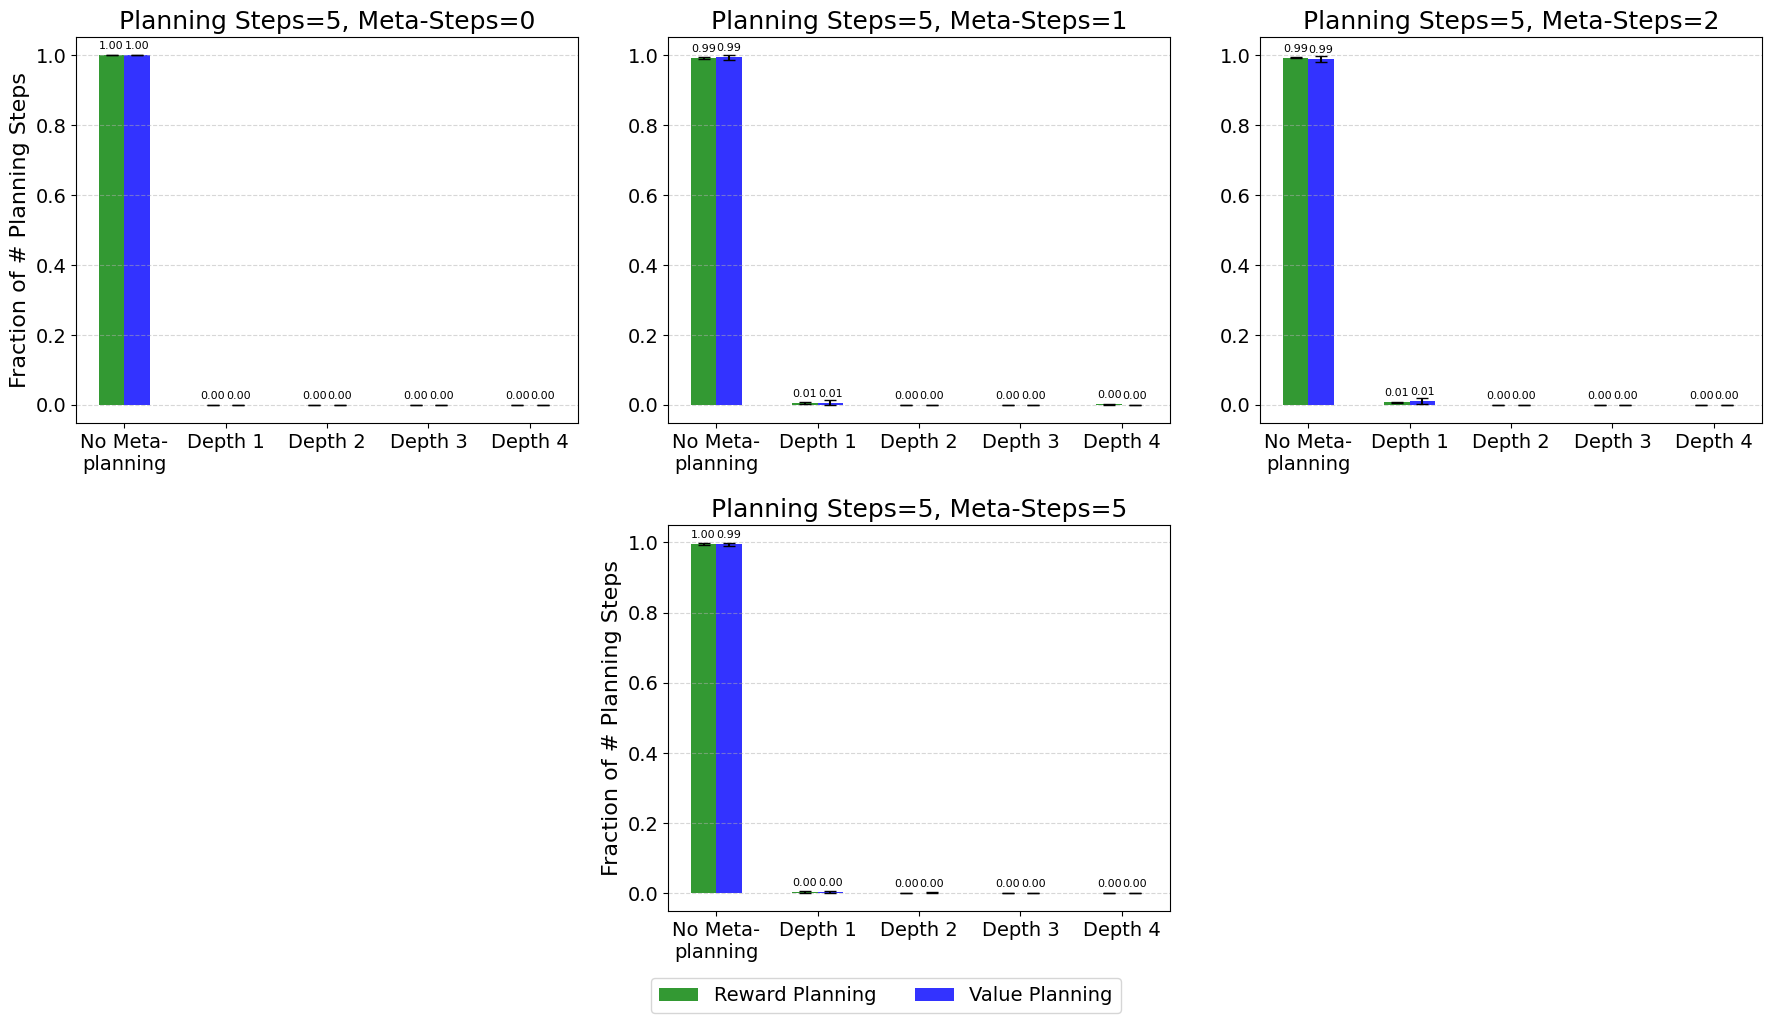

In [16]:
subsets = [
    df[(df["planning_steps"] == 5) & (df["inner_steps"] == inner)]
    for inner in [0, 1, 2, 5]
]
titles = [f"Planning Steps=5, Meta-Steps={i}" for i in [0, 1, 2, 5]]

plot_meta_depth_grid(subsets, titles=titles)

# Num Planning steps

In [17]:
def plot_num_planning_subset(ax, subset, x_col, xlabel, title=None, ylabel=False):
    for mode, color in [("reward", "green"), ("value", "blue")]:
        sub = subset[subset["mode"] == mode].dropna(subset=["num_planning_steps_mean"])
        if sub.empty:
            continue

        x = sub[x_col].values
        y = sub["num_planning_steps_mean"].values
        yerr = sub["num_planning_steps_std"].values

        # Plot mean line
        ax.plot(x, y, label=f"{mode.title()} Planning", color=color, marker="o")

        # Fill between (mean ± std)
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.2)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel("Mean Num Planning Steps")
    ax.grid(True)
    ax.tick_params(axis="y", which="both", labelleft=True)


def plot_num_planning_grid(subsets, x_col, xlabel, titles=None, ncols=3):
    import math
    n = len(subsets)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), sharey=True)
    axes = axes.flatten() if n > 1 else [axes]

    for i, subset in enumerate(subsets):
        col = i % ncols
        plot_num_planning_subset(
            axes[i],
            subset,
            x_col,
            xlabel,
            title=titles[i] if titles else "",
            ylabel=(col == 0)
        )

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center", ncol=2, bbox_to_anchor=(0.5, -0.05))
    fig.tight_layout()
    plt.show()

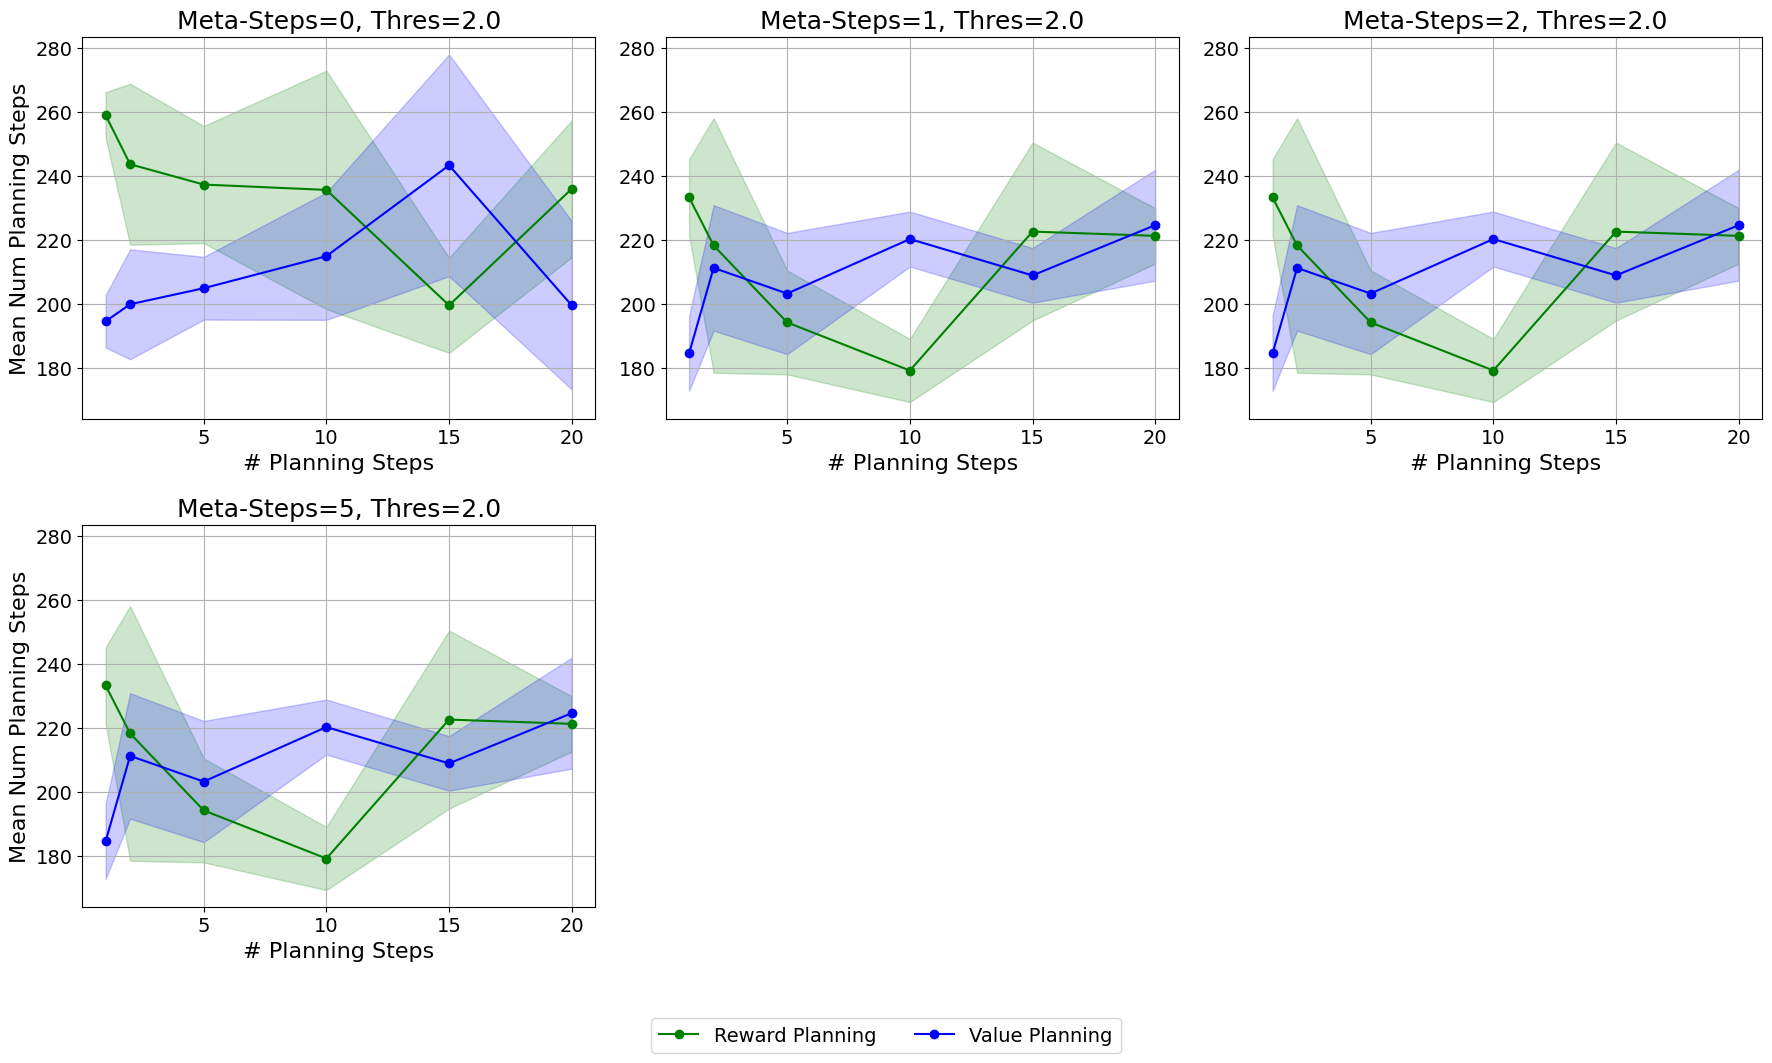

In [18]:
subsets = [
    df[(df["threshold"]==1.0) & (df["inner_steps"]==inner)]
    for inner in [0,1,2,5]
]
titles = [f"Meta-Steps={i}, Thres=2.0" for i in [0,1,2,5]]
plot_num_planning_grid(subsets, "planning_steps", "# Planning Steps", titles=titles)

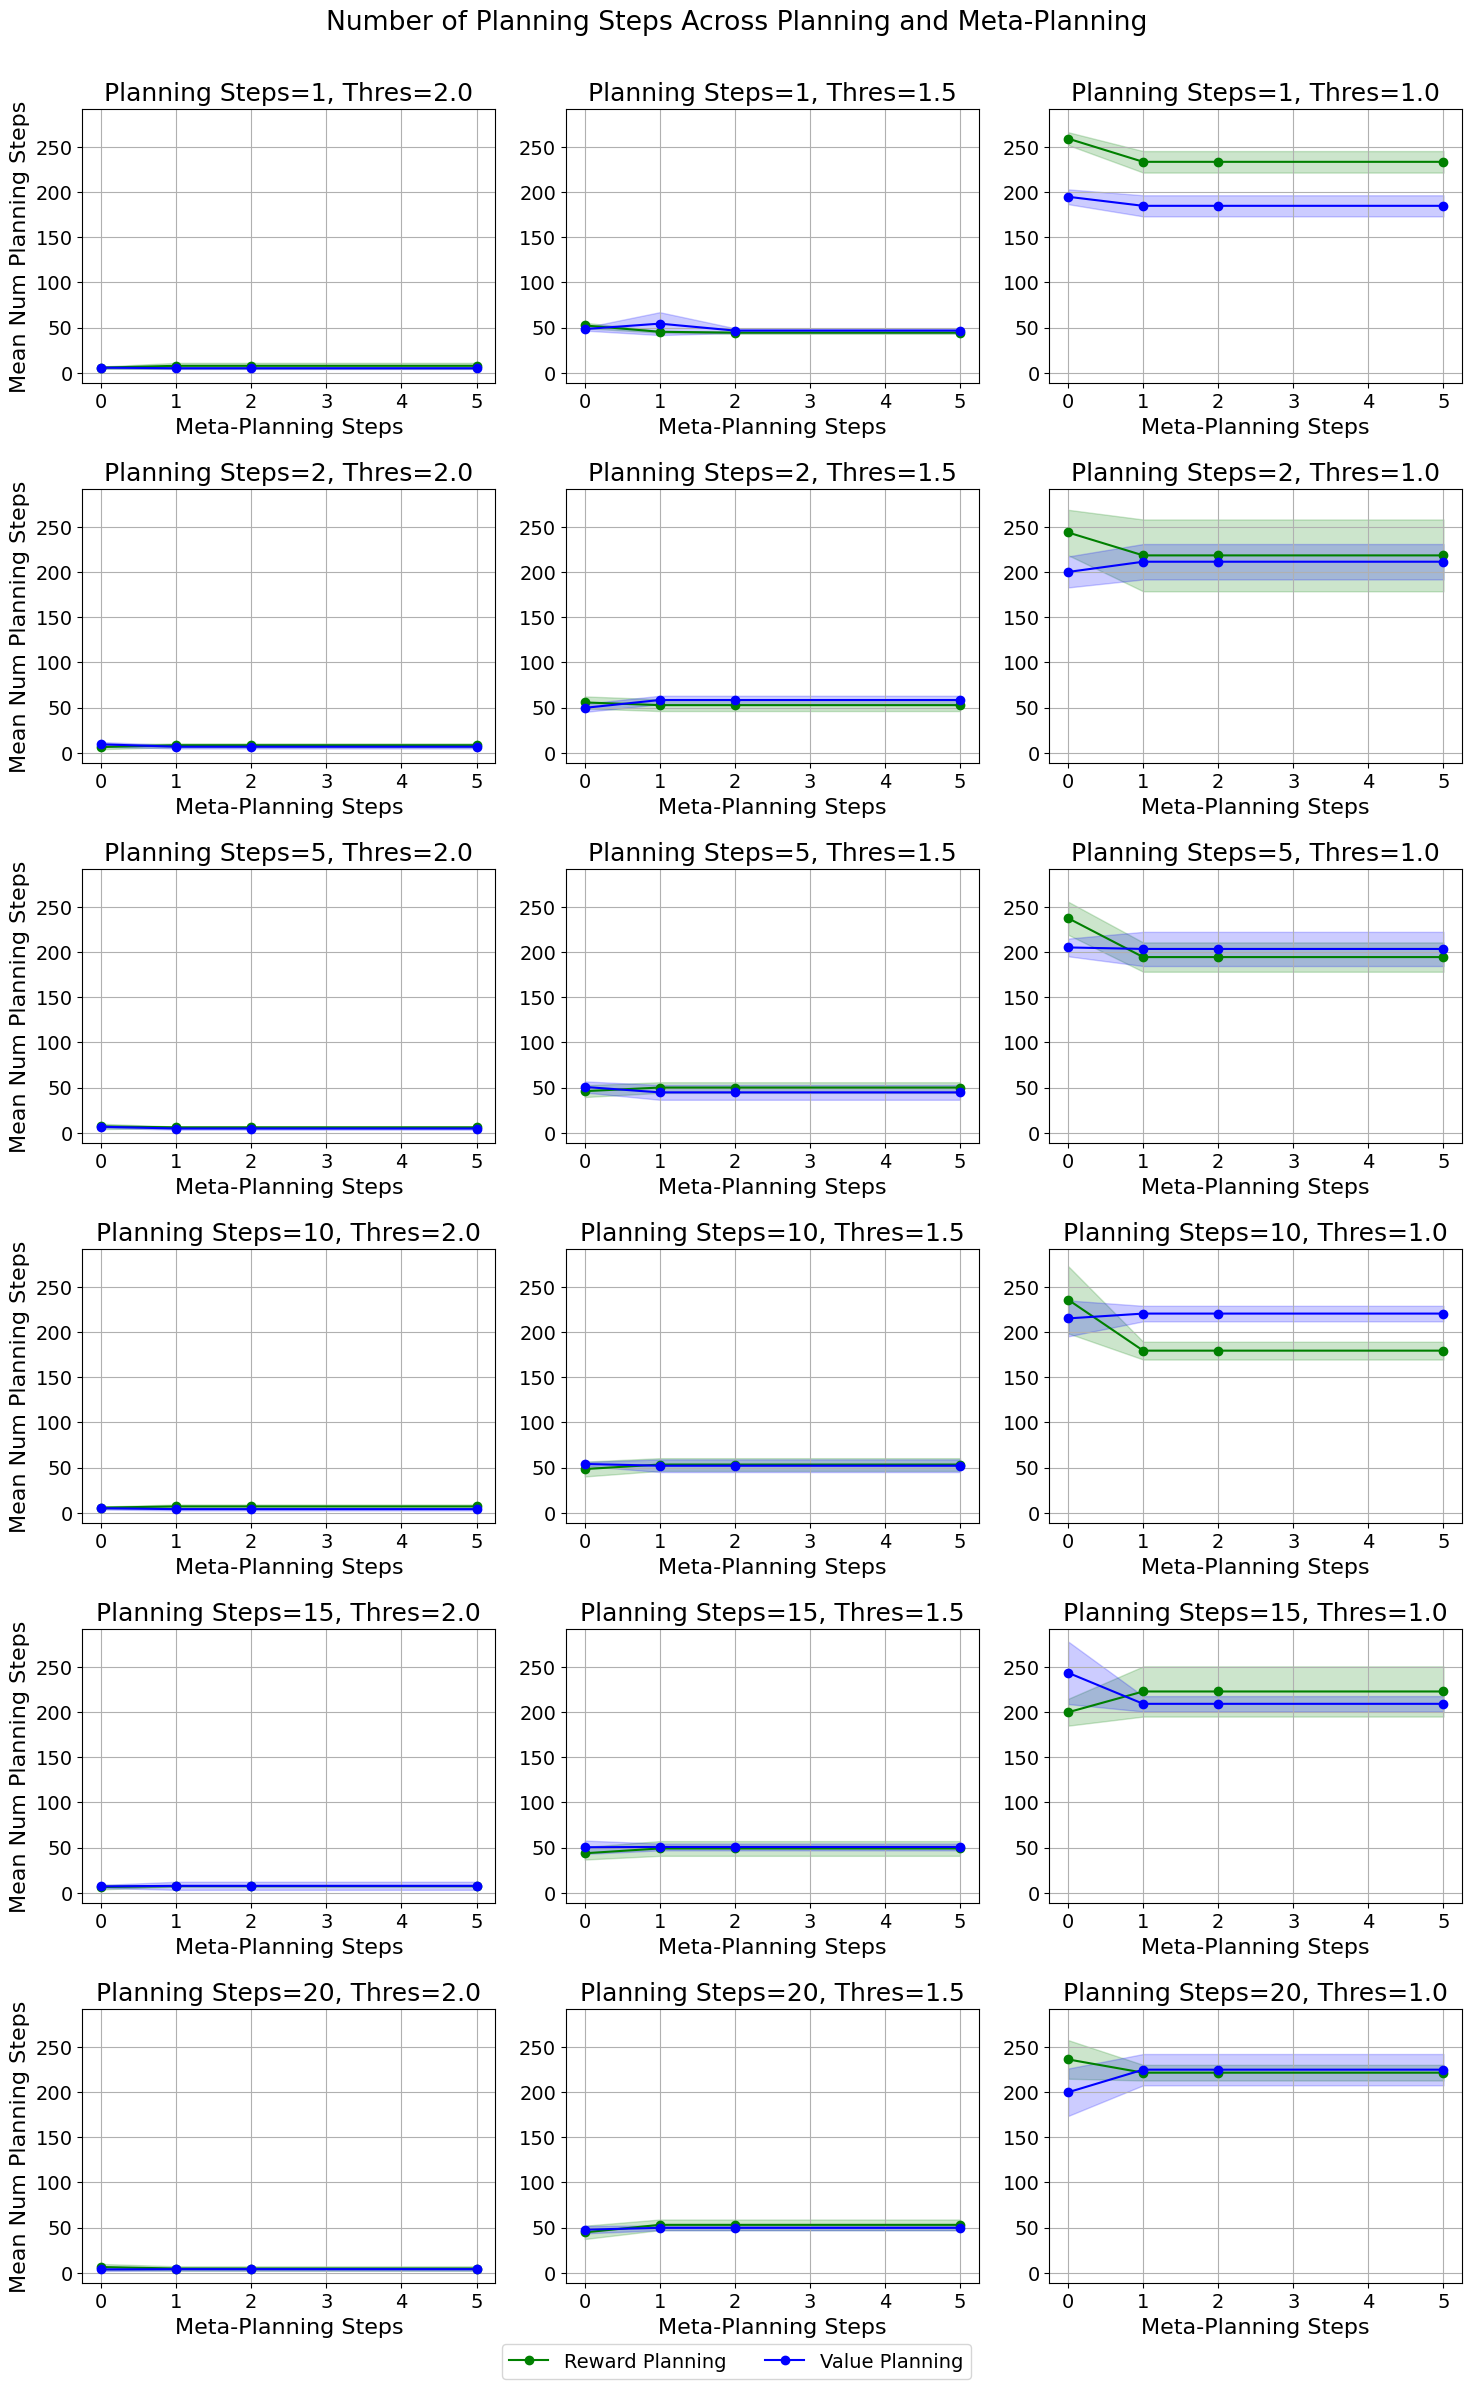

In [19]:
planning_vals = [1, 2, 5, 10, 15, 20]
thresholds = [2.0, 1.5, 1.0]

# Build subsets and titles
subsets = []
titles = []
for p in planning_vals:
    for thr in thresholds:
        subsets.append(df[(df["planning_steps"] == p) & (df["threshold"] == thr)])
        titles.append(f"Planning Steps={p}, Thres={thr}")

# Plot in grid: rows = planning_vals, cols = thresholds
nrows = len(planning_vals)
ncols = len(thresholds)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows), sharey=True)

for i, (subset, title) in enumerate(zip(subsets, titles)):
    r, c = divmod(i, ncols)
    plot_num_planning_subset(
        axes[r, c],
        subset,
        x_col="inner_steps",
        xlabel="Meta-Planning Steps",
        title=title,
        ylabel=(c == 0)  # only leftmost column
    )

# Shared legend
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center", ncol=3, bbox_to_anchor=(0.5, 0))

plt.tight_layout(rect=[0,0,1,0.96])
fig.suptitle("Number of Planning Steps Across Planning and Meta-Planning")
plt.show()

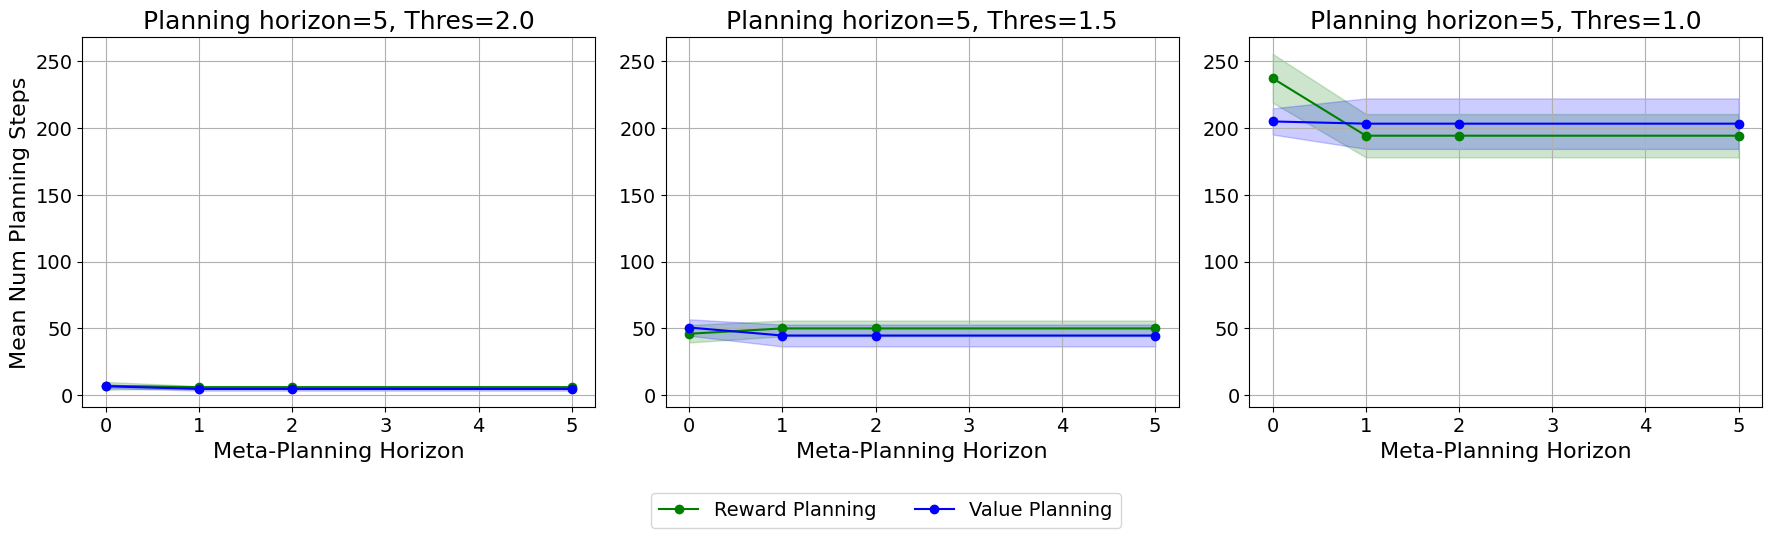

In [20]:
subsets = [
    df[(df["threshold"]==threshold) & (df["planning_steps"]==5)]
    for threshold in [2.0, 1.5, 1.0]
]
titles = [f"Planning horizon=5, Thres={threshold}" for threshold in [2.0, 1.5, 1.0]]
plot_num_planning_grid(subsets, "inner_steps", "Meta-Planning Horizon", titles=titles)

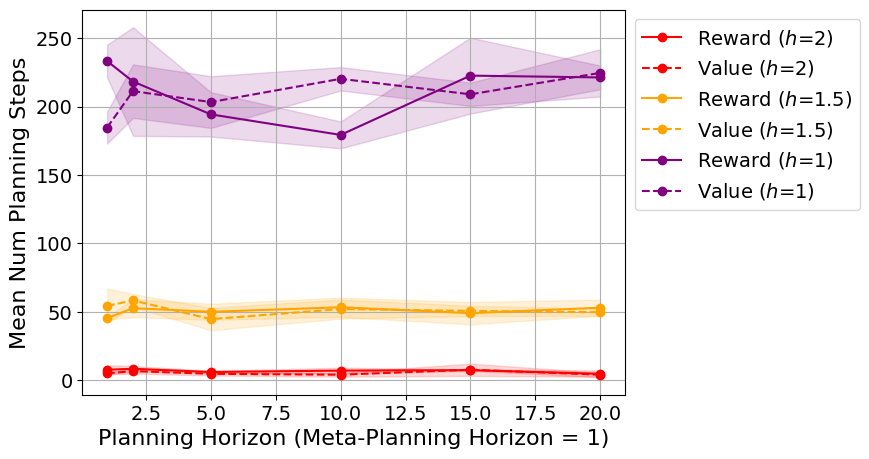

In [21]:
def plot_num_planning_inner_step1(df, x_col="planning_steps"):
    fig, ax = plt.subplots(figsize=(7,5))

    thresholds = [2, 1.5, 1]
    colors = {2: "red", 1.5: "orange", 1: "purple"}
    linestyles = {"reward": "-", "value": "--"}

    sub = df[df["inner_steps"] == 1]

    for thr in thresholds:
        sub_thr = sub[sub["threshold"] == thr]
        if sub_thr.empty:
            continue

        for mode in ["reward", "value"]:
            sub_mode = sub_thr[sub_thr["mode"] == mode].dropna(subset=["num_planning_steps_mean"])
            if sub_mode.empty:
                continue

            x = sub_mode[x_col].values
            y = sub_mode["num_planning_steps_mean"].values
            yerr = sub_mode["num_planning_steps_std"].values

            label = f"{mode.title()} ($h$={thr})"
            ax.plot(x, y, label=label, color=colors[thr], linestyle=linestyles[mode], marker="o")
            ax.fill_between(x, y - yerr, y + yerr, color=colors[thr], alpha=0.15)

    ax.set_xlabel("Planning Horizon (Meta-Planning Horizon = 1)")
    ax.set_ylabel("Mean Num Planning Steps")
    ax.grid(True)
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
    plt.show()

plot_num_planning_inner_step1(df, x_col="planning_steps")

# Miscellaneous Figures

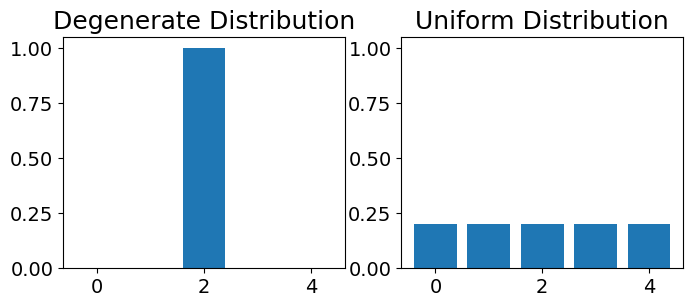

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Discrete domain
x = np.arange(5)

# Degenerate (all mass at x=2)
degenerate = np.zeros_like(x, dtype=float)
degenerate[2] = 1.0

# Uniform
uniform = np.ones_like(x, dtype=float) / len(x)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Left: degenerate distribution
axes[0].bar(x, degenerate)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Degenerate Distribution")

# Right: uniform distribution
axes[1].bar(x, uniform)
axes[1].set_ylim(0, 1.05)  
axes[1].set_title("Uniform Distribution")

# plt.ylim(0, 1)
plt.show()

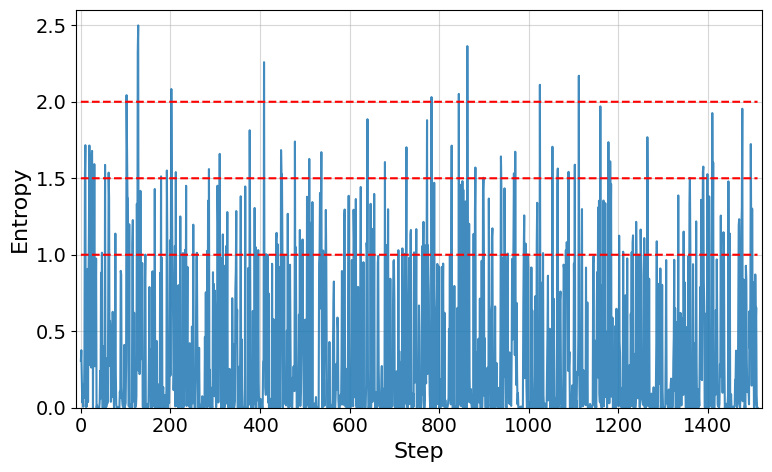

In [23]:
# Load CSV
df = pd.read_csv("/Users/Student/wm_inference_diffusion/wandb_export_2025-09-05T12_49_39.091+01_00.csv")

# Extract x and y
x = df.iloc[:, 0]  # first column ("Step")
y = df.iloc[:, 1]  # second column (the entropy values)

# Plot
plt.figure(figsize=(8,5))
plt.plot(x, y, linestyle="-", alpha=0.85)
plt.plot(x, [2 for _ in range(len(x))], linestyle="--", color="red")
plt.plot(x, [1.5 for _ in range(len(x))], linestyle="--", color="red")
plt.plot(x, [1 for _ in range(len(x))], linestyle="--", color="red")
plt.ylim(0, 2.6)
plt.xlim(-10, max(x)+10)
plt.xlabel("Step")
plt.ylabel("Entropy")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

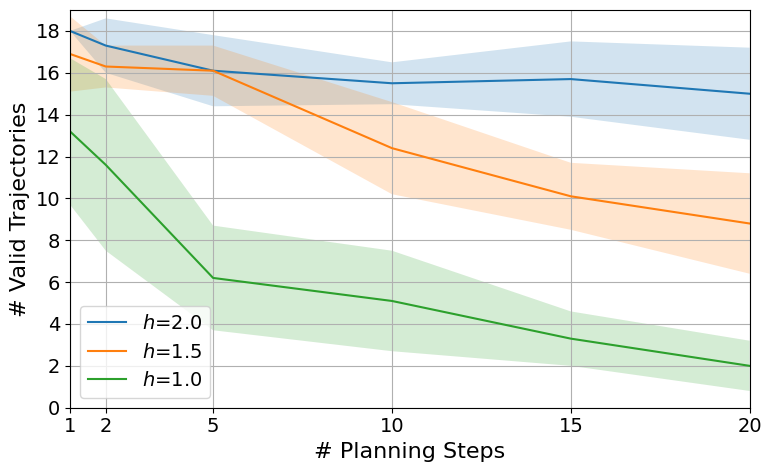

In [24]:
# Mean valid trajectories
x = [1, 2, 5, 10, 15, 20]
means_2 = [18, 17.3, 16.1, 15.5, 15.7, 15]
means_1_5 = [16.9, 16.3, 16.1, 12.4, 10.1, 8.8]
means_1 = [13.2, 11.6, 6.2, 5.1, 3.3, 2]

vars_2 = [0, 1.3, 1.7, 1, 1.8, 2.2]
vars_1_5 = [1.8, 1, 1.2, 2.2, 1.6, 2.4]
vars_1 = [3.5, 4.1, 2.5, 2.4, 1.3, 1.2]

# Plot each mean + std band
plt.figure(figsize=(8,5))

plt.plot(x, means_2, label=r"$h$=2.0")
plt.fill_between(x, np.array(means_2) - np.array(vars_2), 
                    np.array(means_2) + np.array(vars_2), 
                    alpha=0.2)

plt.plot(x, means_1_5, label=r"$h$=1.5")
plt.fill_between(x, np.array(means_1_5) - np.array(vars_1_5), 
                    np.array(means_1_5) + np.array(vars_1_5), 
                    alpha=0.2)

plt.plot(x, means_1, label=r"$h$=1.0")
plt.fill_between(x, np.array(means_1) - np.array(vars_1), 
                    np.array(means_1) + np.array(vars_1), 
                    alpha=0.2)

plt.xlabel("# Planning Steps")
plt.ylabel("# Valid Trajectories")
# plt.title("Comparison across thresholds")
plt.xticks(x, labels=[str(val) for val in x])
plt.yticks(np.arange(0, 19, 2))
plt.ylim(0, 19)
plt.xlim(1, 20)
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/Student/wm_inference_diffusion/src/pruned_sweep_results.csv")
# ensure correct types
df['planning_steps'] = df['planning_steps'].astype(int)
df['inner_steps'] = df['inner_steps'].astype(int)
df['threshold'] = df['threshold'].astype(float)

# baseline: reward, planning_steps==0, inner==0, threshold==2.0 (or choose)
baseline_row = df[(df['mode']=='reward') & (df['planning_steps']==0) & (df['inner_steps']==0)]
if not baseline_row.empty:
    base_reward = baseline_row['reward_mean'].values[0]
    base_std = baseline_row['reward_std'].values[0] if not pd.isna(baseline_row['reward_std'].values[0]) else 0.0
else:
    base_reward = None
    base_std = None

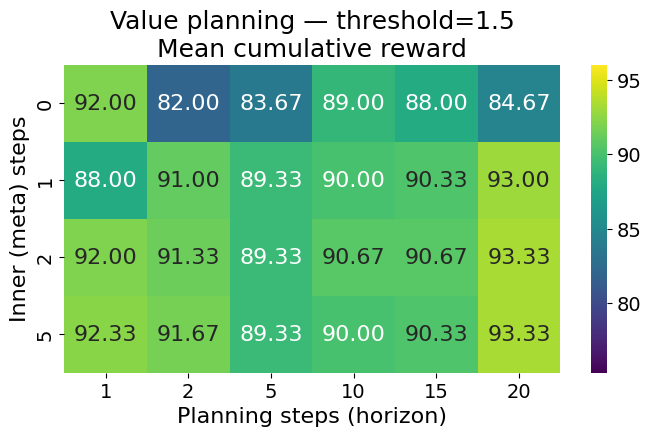

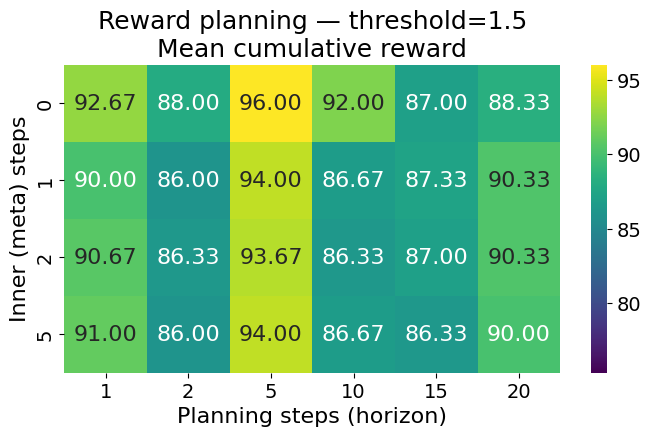

In [26]:
def plot_heatmap_for(mode='value', threshold=1.5):
    subset = df[(df['mode']==mode) & (df['threshold']==float(threshold))]
    pivot = subset.pivot_table(index='inner_steps', columns='planning_steps', values='reward_mean', aggfunc='mean')
    plt.figure(figsize=(8,4))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap='viridis', vmin=df['reward_mean'].min(), vmax=df['reward_mean'].max())
    plt.title(f"{mode.title()} planning — threshold={threshold}\nMean cumulative reward")
    plt.xlabel("Planning steps (horizon)")
    plt.ylabel("Inner (meta) steps")
    plt.show()

# Example:
plot_heatmap_for('value', 1.5)
plot_heatmap_for('reward', 1.5)

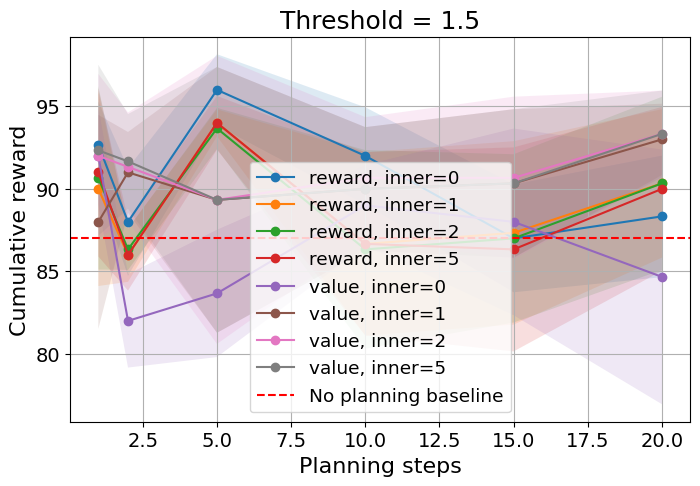

In [27]:
def plot_reward_vs_planning(threshold=1.5, modes=['reward','value'], inner_list=[0,1,2,5]):
    plt.figure(figsize=(8,5))
    for mode in modes:
        for inner in inner_list:
            subset = df[(df['mode']==mode) & (df['threshold']==threshold) & (df['inner_steps']==inner)]
            subset = subset.dropna(subset=['reward_mean'])
            if subset.empty: 
                continue
            x = subset['planning_steps']
            y = subset['reward_mean']
            yerr = subset['reward_std'].fillna(0)
            label = f"{mode}, inner={inner}"
            plt.plot(x, y, marker='o', label=label)
            plt.fill_between(x, y-yerr, y+yerr, alpha=0.15)
    if base_reward is not None:
        plt.axhline(base_reward, linestyle='--', color='red', label='No planning baseline')
    plt.xlabel("Planning steps")
    plt.ylabel("Cumulative reward")
    plt.title(f"Threshold = {threshold}")
    plt.legend(loc='best', fontsize='small')
    plt.grid(True)
    plt.show()

plot_reward_vs_planning(1.5)

In [28]:
def improvement_plot(threshold=1.5, inner_fixed=1):
    rows = df[(df['threshold']==threshold) & (df['inner_steps']==inner_fixed)]
    # pivot
    pivot = rows.pivot_table(index='planning_steps', columns='mode', values='reward_mean', aggfunc='mean')
    if base_reward is None:
        print("No baseline found; compute baseline separately.")
        return
    pivot = pivot - base_reward
    pivot.plot(kind='bar', figsize=(8,4))
    plt.axhline(0, color='k', linewidth=0.8)
    plt.ylabel("Reward Difference from Baseline")
    plt.title(f"Improvement over baseline (inner={inner_fixed}, threshold={threshold})")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

def improvement_subplot(thresholds, inner_fixed=1, base_reward=None, ncols=3):
    """
    Plot improvement-over-baseline bar charts with error bars for multiple thresholds.
    thresholds: list of threshold values to plot
    """
    n = len(thresholds)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharey=True)
    axes = axes.flatten()

    colors = {"reward": "green", "value": "blue"}

    for i, thr in enumerate(thresholds):
        ax = axes[i]
        rows = df[(df['threshold'] == thr) & (df['inner_steps'] == inner_fixed)]

        # Pivot both means and stds
        pivot_mean = rows.pivot_table(index="planning_steps", columns="mode",
                                      values="reward_mean", aggfunc="mean")
        pivot_std = rows.pivot_table(index="planning_steps", columns="mode",
                                     values="reward_std", aggfunc="mean")

        if base_reward is None:
            raise ValueError("No baseline found; compute baseline separately.")

        # Subtract baseline
        pivot_mean = pivot_mean - base_reward

        # Ensure consistent order
        pivot_mean = pivot_mean[["reward", "value"]] if "value" in pivot_mean else pivot_mean[["reward"]]
        pivot_std = pivot_std[pivot_mean.columns]

        # Plot with error bars
        pivot_mean.plot(
            kind="bar", 
            yerr=pivot_std, 
            ax=ax, 
            color=[colors[col] for col in pivot_mean.columns],
            alpha=0.8,
            capsize=3,
            legend=False  # <- no subplot legend
        )

        # annotate numbers on top of bars
        for bar in ax.patches:
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f"{height:.2f}",
                            xy=(bar.get_x() + bar.get_width()/2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha="center", va="bottom", fontsize=8)

        ax.axhline(0, color="k", linewidth=0.8)
        ax.set_ylabel("Reward Δ from Baseline")
        ax.set_xlabel("Planning Steps")
        ax.set_ylim(-15,15)
        ax.set_title(f"Entropy $h$={thr}, Meta-Horizon $m$={inner_fixed}")
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        # x ticks upright
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")

    # Hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    # Shared legend
    handles = [plt.Rectangle((0,0),1,1,color=colors[m]) for m in pivot_mean.columns]
    labels = [m.title() + " Planning" for m in pivot_mean.columns]
    fig.legend(handles, labels, loc="center", ncol=2, bbox_to_anchor=(0.5, -0.05))

    fig.tight_layout()
    plt.show()

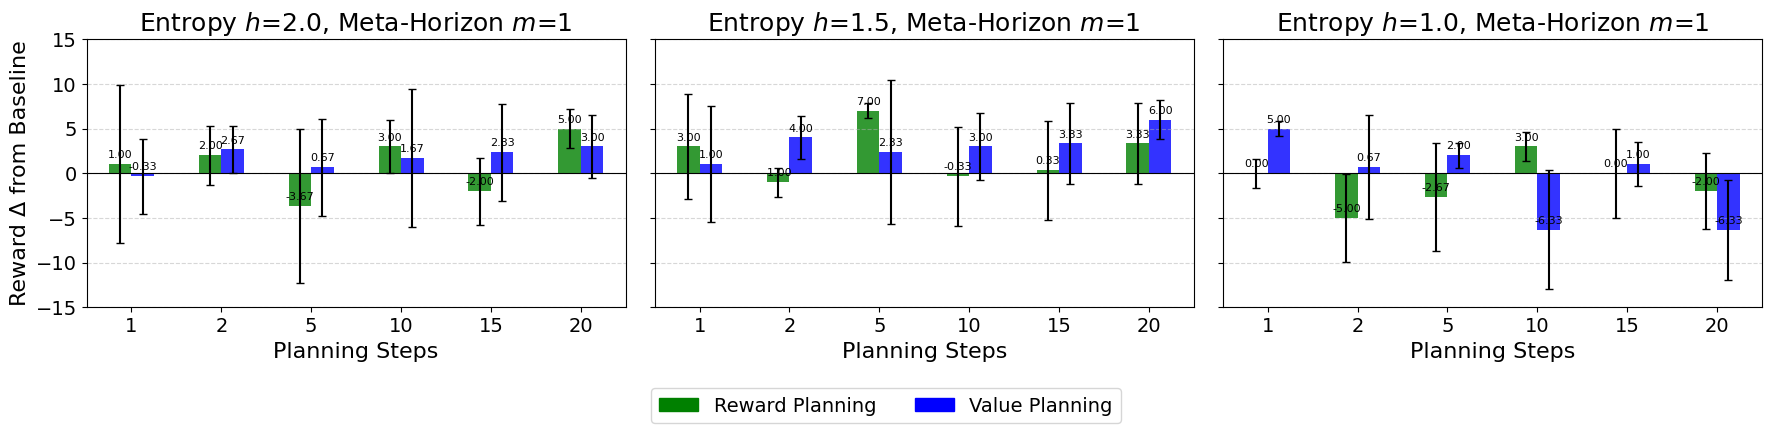

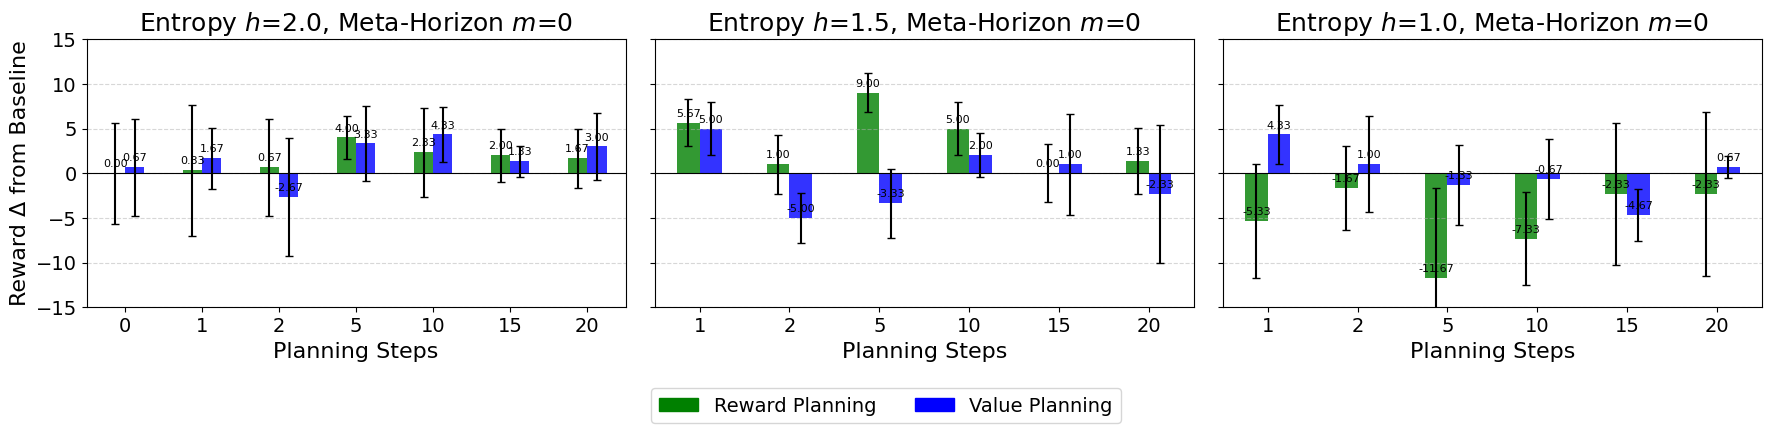

In [29]:
improvement_subplot([2.0, 1.5, 1.0], inner_fixed=1, base_reward=base_reward)
improvement_subplot([2.0, 1.5, 1.0], inner_fixed=0, base_reward=base_reward)